# Analisi sul dataset Ecommerce Order & Supply Chain Dataset 

Obiettivi:
- Riprodurre con pandas almeno le analisi principali realizzate in SQL
- Confrontare i risultati tra SQL e pandas per verificarne la coerenza

Contenuto:
- Informazioni su ordini, righe d’ordine (items), clienti, prodotti, pagamenti e aspetti di supply chain.

In [ ]:
# import library
# data analisys
import pandas as pd 
import numpy as np 
# data visualization
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.dates import DateFormatter, AutoDateLocator
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import matplotlib.ticker as ticker # Importante per formattare i numeri
print(pd.__version__, np.__version__, sns.__version__)

2.3.3 2.3.5 0.13.2


## Comprensione dei Dati (EDA)

In [ ]:
# Import dataset or dataframe / Importo set di dati o dataframe
dfcustomers = pd.read_csv('df_Customers_NEW.csv', low_memory=False)
dfproducts = pd.read_csv('dfproductscopy_NEW.csv', low_memory=False)
dforders = pd.read_csv('dforders_sql.csv', low_memory=False)
dforder_items = pd.read_csv('dforder_items_sql.csv', low_memory=False)
dfpayments = pd.read_csv('dfpayments_sql.csv', low_memory=False)

#leggo le prime 4 righe del dataframe e le visualizzo nello schermo
display(dfcustomers.head(4))
display(dfproducts.head(4))
display(dforders.head(4))
display(dforder_items.head(4))
display(dfpayments.head(4))

,customer_id,customer_zip_code,customer_city,customer_state,customer_country
0,hCT0x9JiGXBQ,58125,varzea paulista,SP,NaN
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ,NaN
2,g3nXeJkGI0Qw,4119,jandira,SP,NaN
3,EOEsCQ6QlpIg,18212,uberlandia,MG,NaN


,product_id,product_category,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0


,order_id,customer_id,order_status,order_date,order_approved_at,delivery_date,estimated_delivery_date,shipping_city,shipping_state
0,001gkk6BwKEB,xKv2nBFnvcwS,delivered,4/16/2018 14:01,4/16/2018 14:32,4/20/2018 19:42,5/3/2018,NaN,NaN
1,0029bAIZFMKA,Xcm6u682SuQQ,delivered,2/17/2018 15:04,2/20/2018 7:06,3/22/2018 23:51,3/15/2018,NaN,NaN
2,002Jk8hp9Bhy,l0HoYdeR1BJM,delivered,4/24/2018 9:27,4/25/2018 3:51,4/26/2018 18:17,5/17/2018,NaN,NaN
3,002ohHsWSKrP,z5refCsXE1nS,delivered,5/17/2018 17:09,5/17/2018 20:32,5/21/2018 20:31,5/25/2018,NaN,NaN


,order_item_id,order_id,product_id,seller_id,price,shipping_charges
0,1,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65
1,2,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79
2,3,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38
3,4,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72


,payment_id,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,1,Axfy13Hk4PIk,1,credit_card,1,259.14
1,2,v6px92oS8cLG,1,credit_card,8,382.39
2,3,Ulpf9skrhjfm,1,credit_card,4,249.25
3,4,bwJVWupf2keN,1,credit_card,2,27.79


### Shape e Struttura base - dataframe puliti 
<i>Obiettivo: capire volume e tipi dati.</i>

- 1. Il **dataframe CUSTOMERS** in analisi ha 89,316 righe e 5 colonne.
- 2. Il **dataframe PRODUCTS** in analisi ha 27,308 righe e 6 colonne.
- 3. Il **dataframe ORDERS** in analisi ha 89,316 righe e 9 colonne.
- 4. Il **dataframe ORDER ITEMS** in analisi ha 89,316 righe e 6 colonne.
- 5. Il **dataframe PAYMENTS** in analisi ha 89,316 righe e 6 colonne.

In [64]:
display(dfcustomers.info())
display(dfproducts.info())
display(dforders.info())
display(dforder_items.info())
display(dfpayments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        89316 non-null  object 
 1   customer_zip_code  89316 non-null  int64  
 2   customer_city      89316 non-null  object 
 3   customer_state     89316 non-null  object 
 4   customer_country   0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 3.4+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27308 entries, 0 to 27307
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         27308 non-null  object 
 1   product_category   27308 non-null  object 
 2   product_weight_g   27308 non-null  float64
 3   product_length_cm  27308 non-null  float64
 4   product_height_cm  27308 non-null  float64
 5   product_width_cm   27308 non-null  float64
dtypes: float64(4), object(2)
memory usage: 1.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88907 entries, 0 to 88906
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 88907 non-null  object 
 1   customer_id              88907 non-null  object 
 2   order_status             88907 non-null  object 
 3   order_date               88907 non-null  object 
 4   order_approved_at        88907 non-null  object 
 5   delivery_date            88907 non-null  object 
 6   estimated_delivery_date  88907 non-null  object 
 7   shipping_city            0 non-null      float64
 8   shipping_state           0 non-null      float64
dtypes: float64(2), object(7)
memory usage: 6.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88907 entries, 0 to 88906
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_item_id     88907 non-null  int64  
 1   order_id          88907 non-null  object 
 2   product_id        88907 non-null  object 
 3   seller_id         88907 non-null  object 
 4   price             88907 non-null  float64
 5   shipping_charges  88907 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 4.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88907 entries, 0 to 88906
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   payment_id            88907 non-null  int64  
 1   order_id              88907 non-null  object 
 2   payment_sequential    88907 non-null  int64  
 3   payment_type          88907 non-null  object 
 4   payment_installments  88907 non-null  int64  
 5   payment_value         88907 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 4.1+ MB


None

### Tabelle di Aggregazione e Group By

#### 1. Tabella di aggregazione per Vendite nel tempo
- Andando a mostrare l'andamento del fatturato per mese
- Identiﬁcazione di eventuali pattern di stagionalità o periodi di picco

<i>Ragionamento</i>: Calcola il fatturato per mese in base allo stato dell'ordine, filtrando quelli ordinati con stato <b>consegnato, fatturato e spedito</b>, escludendo gli ordini con stato approvato, annullato, in elaborazione e non disponibile.

In [ ]:
# Merge the two dataframes on 'order_id' / Unisco i due dataframe su 'order_id'
merged_df = pd.merge(dforders, dforder_items, on='order_id')

# Filter the merged dataframe for the relevant order statuses /Filtro il dataframe unito per gli stati degli ordini rilevanti
relevant_statuses = ['delivered', 'invoiced', 'shipped']
filtered_df = merged_df[merged_df['order_status'].isin(relevant_statuses)].copy()

# Convert 'order_date' to datetime objects to enable time-series analysis
# Converto 'order_date' in oggetti datetime per abilitare l'analisi delle serie temporali
filtered_df['order_date'] = pd.to_datetime(filtered_df['order_date'])

# Extract month and year for grouping, or group directly by month using a DatetimeIndex
# Estraggo mese e anno per il raggruppamento oppure raggruppa direttamente per mese utilizzando un DatetimeIndex
# Set 'order_date' as the index for time-based grouping using pd.Grouper / Imposta 'order_date' come indice per il raggruppamento basato sul tempo utilizzando pd.Grouper
filtered_df = filtered_df.set_index('order_date')

#filtered_df['month'] = filtered_df['order_date'].dt.to_period('M')

# Group by month and calculate the total sales (sum of 'price') for each month
# Raggruppo per mese e calcola le vendite totali (somma del "prezzo") per ogni mese
# Using pd.Grouper(freq='MS') to group by month start frequency
monthly_sales_trend = filtered_df.groupby(pd.Grouper(freq='MS'))['price'].sum().reset_index()

# Rename columns for clarity /Rinomino le colonne per maggiore chiarezza
monthly_sales_trend.columns = ['Year & Month', 'Monthly Sales']

# Display the monthly sales trends / Visualizza le tendenze delle vendite mensili
print(monthly_sales_trend.head(25))

   Year & Month  Monthly Sales
0    2016-09-01         895.07
1    2016-10-01       88700.18
2    2016-11-01           0.00
3    2016-12-01         215.94
4    2017-01-01      235897.13
5    2017-02-01      434133.12
6    2017-03-01      815484.56
7    2017-04-01      724619.60
8    2017-05-01     1018352.93
9    2017-06-01      910175.00
10   2017-07-01     1207960.12
11   2017-08-01     1259989.14
12   2017-09-01     1423870.35
13   2017-10-01     1414695.94
14   2017-11-01     2821755.91
15   2017-12-01     1782056.84
16   2018-01-01     2020393.40
17   2018-02-01     1985096.08
18   2018-03-01     2325544.79
19   2018-04-01     2194523.77
20   2018-05-01     2376580.72
21   2018-06-01     1733439.26
22   2018-07-01     1753189.50
23   2018-08-01     1686958.08
24   2018-09-01         155.40


- Codice che mostra il mese anche se non ci sono state vendite (0,00 Vendite) / Code that shows the month even it had no sales at all (0.00 Sales)

In [112]:
# Merge the two dataframes on 'order_id' / Unisco i due dataframe su 'order_id'
merged_df = pd.merge(dforders, dforder_items, on='order_id')

# Filter the merged dataframe for the relevant order statuses with copy() /Filtro il dataframe unito per gli stati degli ordini rilevanti
# Note: Ensure the status column names match between merged dataframes
relevant_statuses = ['delivered', 'invoiced', 'shipped']
filtered_df = merged_df[merged_df['order_status'].isin(relevant_statuses)].copy()
filtered_df['order_date'] = pd.to_datetime(filtered_df['order_date'])

# 3. Aggregation and convertion order_date to datetime format and create a Month period
# Aggregazione e conversione del formato order_date in datetime e creazione di un periodo mensile
# Use 'month' as the index temporarily to make reindexing easier
# Utilizzo temporaneamente "mese" come indice per semplificare la reindicizzazione
filtered_df['order_date'] = pd.to_datetime(filtered_df['order_date'])
filtered_df['month'] = filtered_df['order_date'].dt.to_period('M')
monthly_sales = filtered_df.groupby(filtered_df['order_date'].dt.to_period('M'))['price'].sum()

# 3. Creo  un intervallo completo di mesi dall'inizio alla fine dei tuoi dati
# Create a full range of months from your data's start to end
full_range = pd.period_range(start=monthly_sales.index.min(), 
                             end=monthly_sales.index.max(), 
                             freq='M')

# Reindex the data to include the full range, filling gaps with 0.00
# Reindicizzare i dati per includere l'intervallo completo, riempiendo gli spazi vuoti con 0,00
monthly_sales_trend = monthly_sales.reindex(full_range, fill_value=0.00).reset_index()
monthly_sales_trend.columns = ['Year & Month', 'Monthly Sales']

# 4. Ensure display shows 0.00 clearly / Assicurarsi che il display mostri chiaramente 0,00
# If you want to keep the decimal .00, don't convert to int. / Se si desidera mantenere il decimale .00, non convertire in int.
# You can format it as a string for the print if desired: / Se lo desideri, puoi formattarlo come stringa per la stampa:
monthly_sales_trend['Monthly Sales'] = monthly_sales_trend['Monthly Sales'].map('{:,.2f}'.format)

# 5. Display head 25 (Now it will show exactly 25 rows if data spans that long)
# Visualizza intestazione 25 (ora mostrerà esattamente 25 righe se i dati si estendono per quella lunghezza)
print(monthly_sales_trend.head(25))

   Year & Month Monthly Sales
0       2016-09        895.07
1       2016-10     88,700.18
2       2016-11          0.00
3       2016-12        215.94
4       2017-01    235,897.13
5       2017-02    434,133.12
6       2017-03    815,484.56
7       2017-04    724,619.60
8       2017-05  1,018,352.93
9       2017-06    910,175.00
10      2017-07  1,207,960.12
11      2017-08  1,259,989.14
12      2017-09  1,423,870.35
13      2017-10  1,414,695.94
14      2017-11  2,821,755.91
15      2017-12  1,782,056.84
16      2018-01  2,020,393.40
17      2018-02  1,985,096.08
18      2018-03  2,325,544.79
19      2018-04  2,194,523.77
20      2018-05  2,376,580.72
21      2018-06  1,733,439.26
22      2018-07  1,753,189.50
23      2018-08  1,686,958.08
24      2018-09        155.40


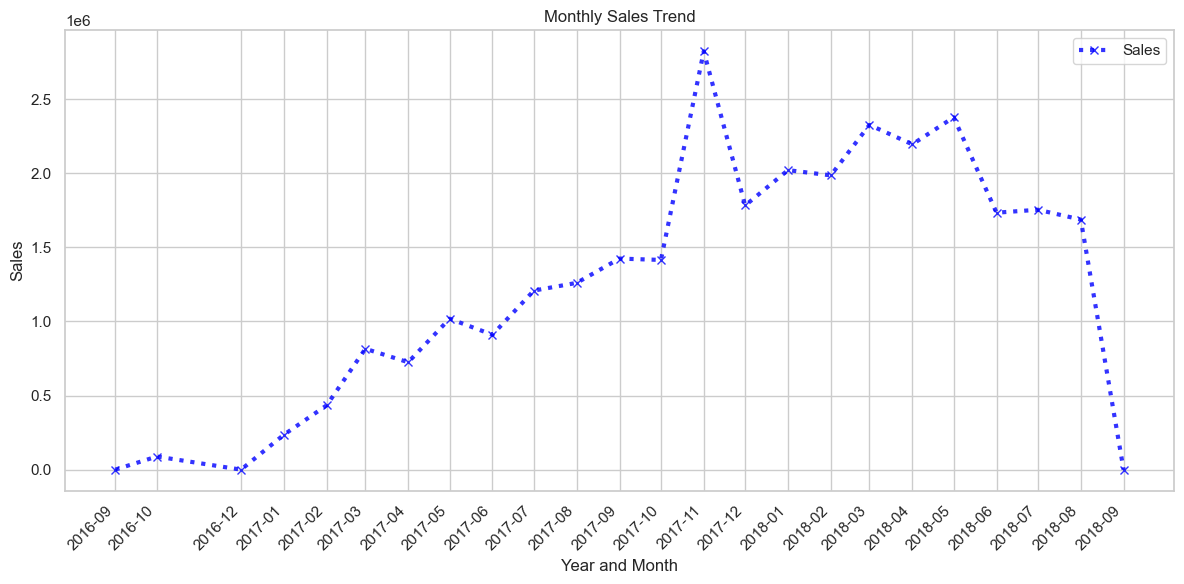

In [111]:
# 1. Merge and Filter / Merge e Filtro
merged_df = pd.merge(dforders, dforder_items, on='order_id')
filtered_df = merged_df[merged_df['order_status'].isin(['delivered', 'invoiced', 'shipped'])].copy()

# 2. Group by Month and Year / Trasformazione data e Raggruppo (Aggregazione)
filtered_df['order_date'] = pd.to_datetime(filtered_df['order_date'])
monthly_sales_trend = filtered_df.groupby(filtered_df['order_date'].dt.to_period('M'))['price'].sum().reset_index()
monthly_sales_trend.columns = ['month', 'Sales']

# 3. Convert period back to timestamp for plotting / CREAZIONE DELLA COLONNA MANCANTE (nel dataframe giusto)
monthly_sales_trend['month_ts'] = monthly_sales_trend['month'].dt.to_timestamp()

# 4. Plot Absolute Sales / PLOT (Usa monthly_sales_trend)
# Assign the chart to an 'ax' variable so we can edit it later / Assegno il grafico a una variabile 'ax' per poterlo modificare dopo
ax = monthly_sales_trend.plot(
    x='month_ts', 
    y='Sales', 
    kind='line', 
    figsize=(12,6),
    title='Monthly Sales Trend',
    grid=True,
    legend=True,
    color='blue',
    style=':',
    alpha=0.8,
    linewidth=3,
    marker='x',
    xlabel='Year and Month',
    ylabel='Sales'
)

# 5. Set Ticks and Labels using the correct data / FIX degli assi (utilizzando l'oggetto ax creato sopra)
# Use the timestamps as the positions for the ticks / Imposto i segnetti (ticks) basandoci sulle date presenti
ax.set_xticks(monthly_sales_trend['month_ts']) 

# 6. Format the labels to make them readable / Formatto le etichette per renderle leggibili (es: 2026-01)
ax.set_xticklabels(monthly_sales_trend['month_ts'].dt.strftime('%Y-%m'))

# 7. Rotate labels for better visibility / Rotazione etichette
ax.tick_params(axis='y', labelrotation=0) 
ax.tick_params(axis='x', labelrotation=45) 

plt.tight_layout()
plt.savefig('Monthly Sales Trend.png', dpi=300, bbox_inches='tight')
plt.show()

#### --- FIX FOR INTEGER VALUES / FIX PER VALORI INTERI ---
- Il grafico mostra le vendite totali mensili e identifica i trend stagionali, ovvero le stagioni o i periodi di picco. L'utilizzo del valore intero garantisce che l'asse Y rimanga pulito, è utile poiché le vendite spesso raggiungono milioni durante i mesi di picco, rendendo superflui i punti decimali per l'individuazione di tendenze di alto livello.

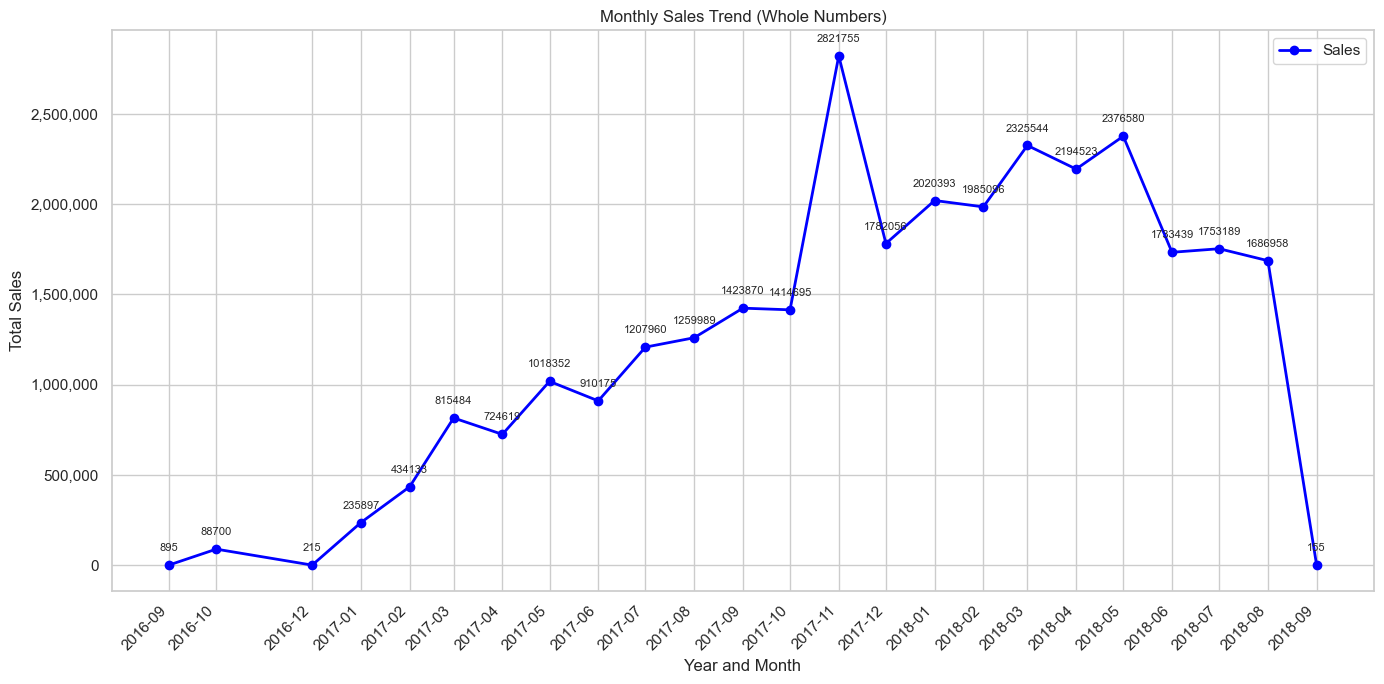

In [113]:
import matplotlib.ticker as ticker # Importante per formattare i numeri

# 1. Merge and Filter / Merge e Filtro
merged_df = pd.merge(dforders, dforder_items, on='order_id')
filtered_df = merged_df[merged_df['order_status'].isin(['delivered', 'invoiced', 'shipped'])].copy()
filtered_df['order_date'] = pd.to_datetime(filtered_df['order_date'])

# 2. Aggregation and Conversion to Integer / Aggregazione e conversione in Intero
monthly_sales_trend = filtered_df.groupby(filtered_df['order_date'].dt.to_period('M'))['price'].sum().reset_index()
monthly_sales_trend.columns = ['month', 'Sales']
# 3. Convert sales to integers for security / Converto i sales in interi per sicurezza
monthly_sales_trend['Sales'] = monthly_sales_trend['Sales'].astype(int)
monthly_sales_trend['month_ts'] = monthly_sales_trend['month'].dt.to_timestamp()

# 4. Plot Absolute Sales / PLOT (Usa monthly_sales_trend)
# Assign the chart to an 'ax' variable so we can edit it later / Assegno il grafico a una variabile 'ax' per poterlo modificare dopo
ax = monthly_sales_trend.plot(
    x='month_ts', 
    y='Sales', 
    kind='line', 
    figsize=(14,7),
    title='Monthly Sales Trend (Whole Numbers)',
    grid=True,
    legend=True,
    color='blue',
    marker='o',
    linewidth=2,
    xlabel='Year and Month',
    ylabel='Total Sales'
)

# --- FIX FOR INTEGER VALUES / FIX PER VALORI INTERI ---

# A. Removes decimals from the Y-axis / Rimuove i decimali dall'asse Y
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# B. (Optional) Adds the numerical value above each point on the chart / (Opzionale) Aggiunge il valore numerico sopra ogni punto del grafico
for i, row in monthly_sales_trend.iterrows():
    ax.annotate(f"{row['Sales']}", 
                (row['month_ts'], row['Sales']),
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', 
                fontsize=8
                #fontweight='bold'
                )

# C. X-Axis Tick Configuration / Configurazione tick asse X
ax.set_xticks(monthly_sales_trend['month_ts'])
ax.set_xticklabels(monthly_sales_trend['month_ts'].dt.strftime('%Y-%m'), rotation=45)

# 5. Save and Dispplay / Salva e visualizza
plt.tight_layout()
plt.savefig('Monthly Sales Trend Final.png', dpi=300)
plt.show()

#### 2. Clienti
- Top 10 clienti per fatturato complessivo
- Contributo percentuale dei top clienti rispetto al totale

In [115]:
# Join order_items with orders to get customer_id for each price / Unisco order_items con orders per ottenere customer_id per ogni prezzo
merged_df = dforders.merge(dforder_items, on='order_id')

# Filter for specific order statuses using .isin() / Filtro per stati di ordine specifici utilizzando .isin()
valid_statuses = ['delivered', 'invoiced', 'shipped']
df_filtered = merged_df[merged_df['order_status'].isin(valid_statuses)]

# Calculate sales per customer / Calcola le vendite fatturato per cliente
customer_sales = df_filtered.groupby('customer_id')['price'].sum().reset_index()

# Sort to find the Top 10 / Ordina per trovare i primi 10 clienti
top_10_customers = customer_sales.sort_values(by='price', ascending=False).head(10)

# Total sales from all valid orders / Vendite totali da tutti gli ordini validi
total_sales = df_filtered['price'].sum()

# Sales from just the Top 10 customers / Vendite solo dai primi 10 clienti
top_10_sales = top_10_customers['price'].sum()

# Grand total sales - Should be consistent with total_revenue from filtered data
# Totale vendite complessivo: deve essere coerente con total_revenue dai dati filtrati
grand_total_sales = total_sales

# Percentage contribution of Top 10 to Total Sales (aggregate) / Contributo percentuale dei primi 10 alle vendite totali (aggregato
percentage_contribution = (top_10_sales / total_sales) * 100

# Display results
print("Top 10 Customers by Sales:")
print(top_10_customers)
print(f"\nPercentage contribution of Top 10 to Total Sales: {percentage_contribution:.2f}%")

Top 10 Customers by Sales:
        customer_id   price
68034  lwNS6AdlPkdm  6735.0
72202  ondvZDYSibyo  6499.0
22258  FhI8lkm1yu6D  4799.0
68302  m84WdTDI0jlP  4799.0
65846  kRm3xxmQrNwq  4799.0
30408  LXBxeq9Kt6by  4799.0
2419   1jvmBfVozjRM  4799.0
4068   2tbvqYSvWXnH  4690.0
70961  nvIwohKq2qSI  4690.0
85064  xjCS9XXFYshd  4590.0

Percentage contribution of Top 10 to Total Sales: 0.17%


In [117]:
# Join order_items with orders to get customer_id for each price / Unisco order_items con orders per ottenere customer_id per ogni prezzo
merged_df = dforders.merge(dforder_items, on='order_id')

# Filter for specific order statuses using .isin() / Filtro per stati di ordine specifici utilizzando .isin()
valid_statuses = ['delivered', 'invoiced', 'shipped']
df_filtered = merged_df[merged_df['order_status'].isin(valid_statuses)]

# Calculate sales per customer / Calcola le vendite fatturato per cliente
customer_sales = df_filtered.groupby('customer_id')['price'].sum().reset_index()

# Sort to find the Top 10 / Ordina per trovare i primi 10 clienti
top_10_customers = customer_sales.sort_values(by='price', ascending=False).head(10)

# Total sales from all valid orders / Vendite totali da tutti gli ordini validi
total_sales  = df_filtered['price'].sum()

# Sales from just the Top 10 customers / Vendite solo dai primi 10 clienti
top_10_sales = top_10_customers['price'].sum()

# Calculate individual percentage contribution for each of the top 10 customers / Calcola la percentuale di contributo individuale per ciascuno dei primi 10 clienti
top_10_customers['percentage_contribution'] = (top_10_customers['price'] / total_sales ) * 100

# Percentage contribution of Top 10 to Total Sales (aggregate) / Contributo percentuale dei primi 10 alle vendite totali (aggregato)
percentage_contribution = (top_10_sales / total_sales ) * 100

# Rename columns for clarity / Rinomino le colonne per maggiore chiarezza
top_10_customers.rename(columns={
    'customer_id': 'Customer ID',
    'price': 'Customer Total Sales',
    'percentage_contribution': 'Percentage Contribution'
}, inplace=True)

# Display results / Visualizza i risultati
#print("Top 10 Customers by Sales and their individual percentage contribution:")
print(top_10_customers)
print(f"\nAggregate percentage contribution of Top 10 to Total Sales: {percentage_contribution:.2f}%")

        Customer ID  Customer Total Sales  Percentage Contribution
68034  lwNS6AdlPkdm                6735.0                 0.022290
72202  ondvZDYSibyo                6499.0                 0.021509
22258  FhI8lkm1yu6D                4799.0                 0.015883
68302  m84WdTDI0jlP                4799.0                 0.015883
65846  kRm3xxmQrNwq                4799.0                 0.015883
30408  LXBxeq9Kt6by                4799.0                 0.015883
2419   1jvmBfVozjRM                4799.0                 0.015883
4068   2tbvqYSvWXnH                4690.0                 0.015522
70961  nvIwohKq2qSI                4690.0                 0.015522
85064  xjCS9XXFYshd                4590.0                 0.015191

Aggregate percentage contribution of Top 10 to Total Sales: 0.17%


#### Questo grafico è un riepilogo delle performance di alto livello. Risponde a due domande aziendali fondamentali:
- 1. Chi genera più cassa? (Barre Verdi)
- 2. Quanto incide ogni individuo sul risultato finale totale dell'azienda? (Linea Rossa)

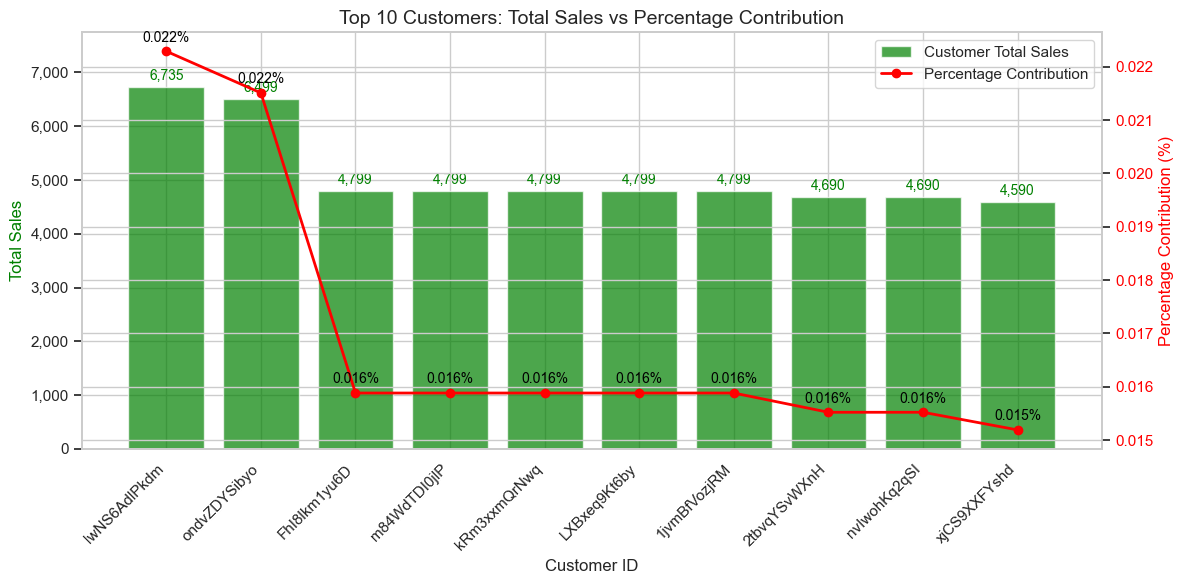

In [118]:
# 1. Create the Figure and First Axis (Sales) / Creazione della figura e del primo asse (Sinistro - Sales)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Bar Chart: Customer Total Sales / Grafico a Barre: Customer Total Sales
bar_color = 'green'
bars = ax1.bar(top_10_customers['Customer ID'], top_10_customers['Customer Total Sales'], 
               color=bar_color, label='Customer Total Sales', alpha=0.7)
ax1.set_xlabel('Customer ID', fontsize=12)
ax1.set_ylabel('Total Sales', fontsize=12, color='green')

# 2.A. Add data values / Aggiunto etichette dati
# fmt='{:,.0f}' formatta i numeri con separatore di migliaia e senza decimali
ax1.bar_label(bars, padding=3, fmt='{:,.0f}', fontsize=10, color='green')

# 2.B. To give the labels some breathing room, we'll slightly increase the upper limit of the Y-axis
# Aumento leggermente l'estensione dell'asse Y per evitare sovrapposizioni con le etichette.
ax1.set_ylim(0, top_10_customers['Customer Total Sales'].max() * 1.15)

# 2.C. I set the positions (0 to 9) and labels simultaneously / Imposto le posizioni (da 0 a 9) e le etichette contemporaneamente
ax1.set_xticks(range(len(top_10_customers)))
ax1.set_xticklabels(top_10_customers['Customer ID'], rotation=45, ha='right')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 3. Create the Second Axis (Right - Percentage) / Creazione del secondo asse (Destro - Percentage)
ax2 = ax1.twinx() 
line_color = 'red'
line = ax2.plot(top_10_customers['Customer ID'], top_10_customers['Percentage Contribution'], 
                color=line_color, marker='o', linewidth=2, label='Percentage Contribution')
ax2.set_ylabel('Percentage Contribution (%)', fontsize=12, color=line_color)
ax2.tick_params(axis='y', labelcolor=line_color)

# 3.A. Add data labels to the line graph / Aggiunto etichette dati alla linea
for i, val in enumerate(top_10_customers['Percentage Contribution']):
    ax2.annotate(f'{val:.3f}%', 
                 xy=(i, val), 
                 xytext=(0, 7),             # Spostamento di 7 punti sopra il marker
                 textcoords="offset points", 
                 ha='center', 
                 fontsize=10, 
                 color='black'
                 #fontweight='bold'
                 )

# 4. Unified Legend / Gestione della Legenda Unificata
# Retrieve labels from both axes to display them in a single box / Recupero le label da entrambi gli assi per mostrarle in un'unica box
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

# 5. Save and Dispplay / Salva e visualizza
plt.title('Top 10 Customers: Total Sales vs Percentage Contribution', fontsize=14)
fig.tight_layout() # Ottimizza gli spazi per evitare sovrapposizioni di label
plt.savefig('Top 10 Customers by Sales and Percentage Contribution.png', dpi=300)
plt.show()

- Asse X: Clienti classificati dal fatturato totale più elevato a quello più basso.

- Asse Y: Vendite cumulative.

- Filtro Stato Ordine: Filtrando per consegnato, fatturato e spedito, catturiamo quasi tutte le transazioni che generano fatturato, escludendo gli ordini annullati, il che fornisce una visione più accurata dell'effettivo successo commerciale.
- Conversione di numeri interi: l'utilizzo di .astype(int) garantisce che il mio asse Y rimanga pulito, il che è utile poiché le vendite spesso raggiungono milioni di unità durante i mesi di punta, rendendo superflui i punti decimali per l'individuazione di tendenze di alto livello.
- Limite dati: si noti che la maggior parte delle versioni di questo set di dati termina bruscamente a settembre 2018, il che mostrerà un netto calo artificiale nel mio grafico che non riflette le effettive prestazioni aziendali.

#### 3. Prodotti e categorie
- Prodotti e categorie con maggior fatturato e/o quantità vendute.

In [126]:
# 1. Filter orders based on specific status / Filtro gli ordini in base allo stato specifico
valid_statuses = ['delivered', 'invoiced', 'shipped']
filtered_orders = dforders[dforders['order_status'].isin(valid_statuses)]

# 2. Merge all dataframes together / Unisco tutti i dataframe insieme
# Note: 'order_id' is the common key for orders and items
merged_df = filtered_orders.merge(dforder_items, on='order_id')

# Note: 'product_id' is the common key for items and products
# If dforder_items_transformed doesn't have product_id, ensure it's available in one of the tables
# Se dforder_items_transformed non ha product_id, assicurati che sia disponibile in una delle tabelle
final_df = merged_df.merge(dfproducts, on='product_id')

# 3. Calculate metrics per Product / Calcolo le metriche per prodotto
top_products = final_df.groupby('product_id').agg(
    total_sales=('price', 'sum'),
    quantity_sold=('product_id', 'count')
).sort_values(by='total_sales', ascending=False)

# 4. Calculate metrics per Category / Calcolo le metriche per categoria
top_categories = final_df.groupby('product_category').agg(
    total_sales=('price', 'sum'),
    quantity_sold=('product_id', 'count')
).sort_values(by='total_sales', ascending=False)

# Display the results / Visualizza i risultati
print("--- Top Products by Sales ---")
print(top_products.head(20))

print("\n--- Top Categories by Sales ---")
print(top_categories.head(20))

--- Top Products by Sales ---
              total_sales  quantity_sold
product_id                              
9NwzO0Pm0fDM    797298.94            383
SLTlrWtcYt1m    566543.44            320
Biwi1BNtUB7l    486503.65            295
ro08JPncYzLh    467133.53            290
ZWyg4uNWPHjJ    318890.00            110
tPlw2QcQOvKf    153366.49             91
utVPLgd1LM3F    146223.00             77
GvBzGCvvIC2D    126959.00            175
5J7az1rwth4i    117385.08            110
CY8OZ3lT9uqB    116979.98             42
7grztYpCkySJ    111454.00            134
CpeCg2UGCL6P    103836.00             64
k1G4RHt3R7Nk    100674.00             90
yhM1TNmnd3og     98566.00             34
kktXNGIh1TrV     89588.80             32
rHSTHjYFnJS8     84733.42            117
hrjNaMt3Wyo5     83808.84             95
bfkYf8WcDtMl     82825.05            101
M9Rq7Nx8etjk     70961.80            135
LeGxEhH8juyh     69668.40             26

--- Top Categories by Sales ---
                                 to

In [127]:
# 1. Filter orders based on specific status / Filtro gli ordini in base allo stato specifico
valid_statuses = ['delivered', 'invoiced', 'shipped']
filtered_orders = dforders[
    dforders['order_status'].isin(valid_statuses)
]

# 2. Merge orders with order items to get prices for valid orders
# Unisco gli ordini con gli articoli dell'ordine per ottenere i prezzi per gli ordini validi
df_valid_items = pd.merge(
    filtered_orders[['order_id']], 
    dforder_items, 
    on='order_id'
)

# 3. Merge with products to get product_id and category
# Unisco con i prodotti per ottenere product_id e category
df_complete = pd.merge(
    df_valid_items, 
    dfproducts, 
    on='product_id'
)

# 4. Aggregate sales and quantity sold per product / Aggregazione vendite e quantità venduta per prodotto
# Group by product and category to get sum of prices and count of sales
# Raggruppo per prodotto e categoria per ottenere la somma dei prezzi e il conteggio delle vendite
# Note: Quantity is calculated by counting order_id occurrences per product / Nota: la quantità viene calcolata contando le occorrenze di order_id per prodotto

product_stats = df_complete.groupby(['product_id', 'product_category']).agg(
    total_sales=('price', 'sum'),
    quantity_sold=('order_id', 'count')
).reset_index()

# 5. Calculate global totals for percentage reference / Calcolo i totali globali per riferimento percentuale
total_sales_sum = product_stats['total_sales'].sum()
total_qty_sum = product_stats['quantity_sold'].sum()

product_stats['sales_percentage'] = (product_stats['total_sales'] / total_sales_sum) * 100
product_stats['quantity_percentage'] = (product_stats['quantity_sold'] / total_qty_sum) * 100

# Round specifically to 2 decimal places / Arrotondare specificamente a 2 cifre decimali
# product_stats['sales_percentage'] = product_stats['sales_percentage'].round(2)
# product_stats['quantity_percentage'] = product_stats['quantity_percentage'].round(2)
product_stats['sales_percentage'] = product_stats['sales_percentage'].map("{:.2f}%".format)
product_stats['quantity_percentage'] = product_stats['quantity_percentage'].map("{:.2f}%".format)

# 6. Display the result, sorted by highest product sales and quantity sold
# Visualizza il risultato, ordinato in base ai prodotti e categorie con maggior fatturato e quantità vendute
result = product_stats.sort_values(by='total_sales', ascending=False)

print(result.head(20))

         product_id product_category  total_sales  quantity_sold  \
4028   9NwzO0Pm0fDM             toys    797298.94            383   
12201  SLTlrWtcYt1m             toys    566543.44            320   
5065   Biwi1BNtUB7l             toys    486503.65            295   
23361  ro08JPncYzLh     garden_tools    467133.53            290   
15335  ZWyg4uNWPHjJ             toys    318890.00            110   
24035  tPlw2QcQOvKf     garden_tools    153366.49             91   
24667  utVPLgd1LM3F             toys    146223.00             77   
7274   GvBzGCvvIC2D             toys    126959.00            175   
2288   5J7az1rwth4i             toys    117385.08            110   
5393   CY8OZ3lT9uqB        telephony    116979.98             42   
3304   7grztYpCkySJ             toys    111454.00            134   
5506   CpeCg2UGCL6P             toys    103836.00             64   
19899  k1G4RHt3R7Nk             toys    100674.00             90   
26343  yhM1TNmnd3og    watches_gifts     98566.0

- Primo: il grafico per i 10 prodotti con maggior fatturato e quantità vendute

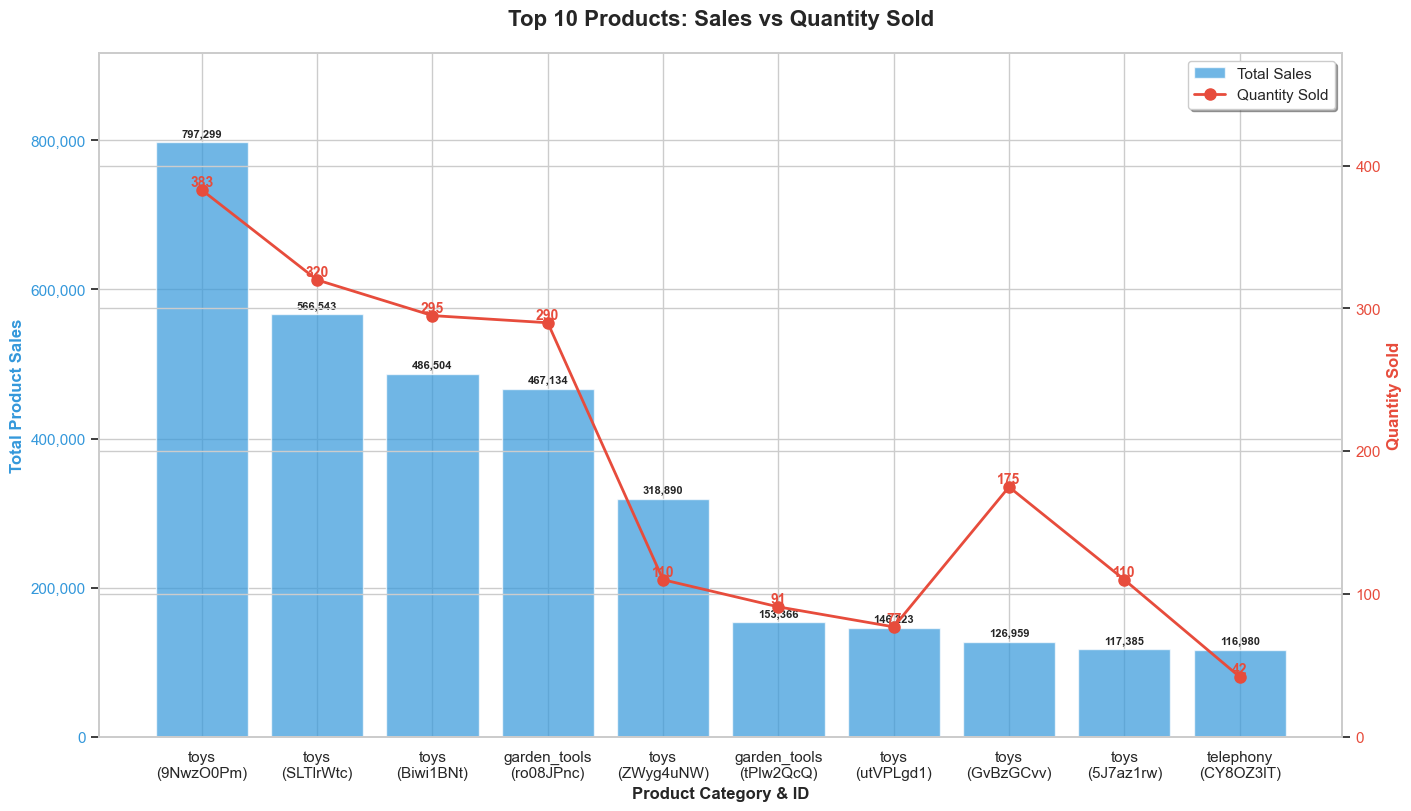

In [128]:
# 1. I select the top 10 products to avoid overlaps in the chart / Prendiamo i top 10 prodotti per evitare sovrapposizioni nel grafico
top_products = result.head(10).copy()

#  2.Creating the string for the X-axis: Category + ID (shortened for readability)
# Creazione della stringa per l'asse X: Categoria + ID (accorciato per leggibilità)
top_products['label'] = top_products['product_category'] + "\n(" + top_products['product_id'].str[:8] + ")"

# 3. Figure configuration with optimized layout (2026 standard)
# Configurazione Figura con layout ottimizzato (2026 standard)
fig, ax1 = plt.subplots(figsize=(14, 8), layout='constrained')

# 4. --- LEFT AXIS: Total Sales (Bars) --- / ASSE SINISTRO: Total Sales (Barre)
color_sales = '#3498db' # Blu
bars = ax1.bar(top_products['label'], top_products['total_sales'], 
               color=color_sales, alpha=0.7, label='Total Sales')

ax1.set_ylabel('Total Product Sales', color=color_sales, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_sales)
ax1.set_xlabel('Product Category & ID', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Add value labels on bars / Aggiunto etichette valori sulle barre
ax1.bar_label(bars, padding=3, fmt='{:,.0f}', fontsize=8, fontweight='bold')

# 5. --- RIGHT AXIS: Quantity Sold (Line) --- / ASSE DESTRO: Quantity Sold (Linea)
ax2 = ax1.twinx()
color_qty = '#e74c3c' # Rosso
line = ax2.plot(top_products['label'], top_products['quantity_sold'], 
                color=color_qty, marker='o', linewidth=2, markersize=8, label='Quantity Sold')

ax2.set_ylabel('Quantity Sold', color=color_qty, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_qty)

# Add value labels on the line / Aggiunto etichette valori sulla linea
for i, val in enumerate(top_products['quantity_sold']):
    ax2.text(i, val + 0.2, str(int(val)), color=color_qty, 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# 6. Improved margins to avoid label cuts / Miglioramento margini per evitare tagli delle etichette
ax1.set_ylim(0, top_products['total_sales'].max() * 1.15)
ax2.set_ylim(0, top_products['quantity_sold'].max() * 1.25)

# 7. Unified Legend / Legenda Unificata
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', shadow=True)

# 8. Save and Dispplay / Salva e visualizza
plt.title('Top 10 Products: Sales vs Quantity Sold', fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.savefig('Top 10 Products by Sales and Quantity Sold.png', dpi=300)
plt.show()

#### Identificazione del VALORE rispetto al VOLUME
- Secondo: il grafico per i 20 prodotti con maggior fatturato e quantità vendute
- Il grafico è un diagramma combinato a due assi che visualizza le prestazioni dei 20 prodotti principali confrontando il valore finanziario con il volume operativo.
- Questo grafico funge da mappa della redditività e della popolarità dei prodotti. Indica se la top 20 è dominata da pochi articoli costosi o da un elevato volume di prodotti più economici, influenzando direttamente la gestione dell'inventario e le strategie di prezzo.

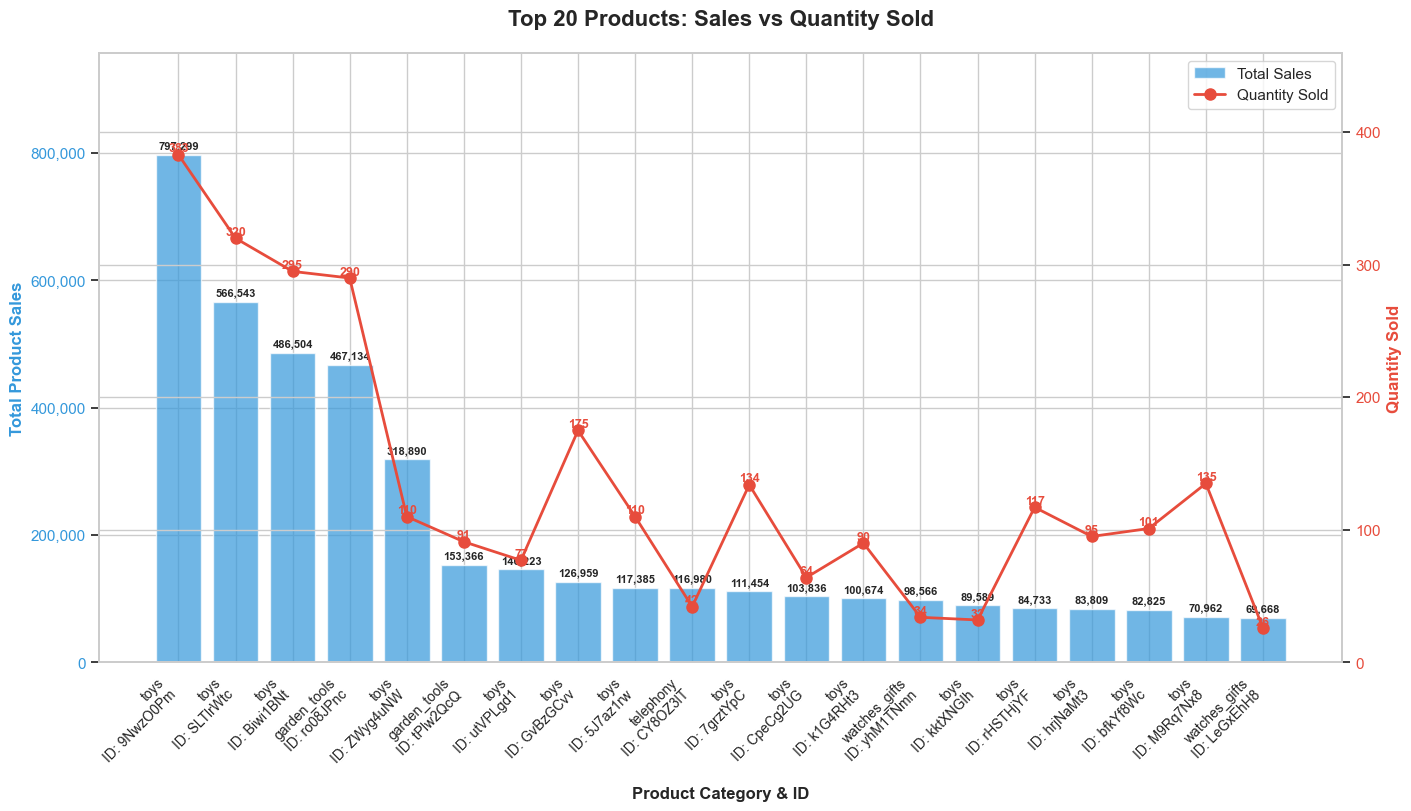

In [129]:
# 1. I select the top 20 products with highest sales and quantity sold / Prendo i top 10 prodotti con maggior fatturato e quantità vendute
top_products = result.head(20).copy()

# 2. Data preparation: Make sure 'label' is a string / Preparazione dei dati: assicurati che 'label' sia una stringa
top_products['label'] = top_products['product_category'] + "\nID: " + top_products['product_id'].str[:8]

fig, ax1 = plt.subplots(figsize=(14, 8), layout='constrained')

# 3. --- LEFT AXIS: Bars --- / --- ASSE SINISTRO: Barre ---
color_sales = '#3498db'
# I use numeric indices for X positions to avoid alignment errors with twinx
# Uso indici numerici per le posizioni X per evitare errori di allineamento con twinx
x_positions = range(len(top_products))
bars = ax1.bar(x_positions, top_products['total_sales'], 
               color=color_sales, alpha=0.7, label='Total Sales')

# IMPOSTAZIONE ETICHETTE ASSE X (Punto cruciale per la visibilità)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(top_products['label'], rotation=45, ha='right', fontsize=10)

ax1.set_ylabel('Total Product Sales', color=color_sales, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_sales)
ax1.set_xlabel('Product Category & ID', fontsize=12, fontweight='bold', labelpad=15)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Value labels on the bars / Metto le etichette valori sulle barre
ax1.bar_label(bars, padding=3, fmt='{:,.0f}', fontsize=8, fontweight='bold')

# 4. --- RIGHT AXIS: Line --- / --- ASSE DESTRO: Linea ---
ax2 = ax1.twinx()
color_qty = '#e74c3c'
line = ax2.plot(x_positions, top_products['quantity_sold'], 
                color=color_qty, marker='o', linewidth=2, markersize=8, label='Quantity Sold')

ax2.set_ylabel('Quantity Sold', color=color_qty, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_qty)

#Value labels on the line / Metto le etichette valori sulla linea
for i, val in enumerate(top_products['quantity_sold']):
    ax2.text(i, val, f'{int(val)}', color=color_qty, 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 5. Limit Optimization / Ottimizzazione limiti
ax1.set_ylim(0, top_products['total_sales'].max() * 1.2)
ax2.set_ylim(0, top_products['quantity_sold'].max() * 1.2)

# 6. Legend and Title / Legenda e Titolo
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Top 20 Products: Sales vs Quantity Sold', fontsize=16, pad=20, fontweight='bold')

# 7. Save and Dispplay / Salva e visualizza
plt.savefig('Top 20 Products by Sales and Quantity Sold.png', dpi=300, bbox_inches='tight')
plt.show()

In [133]:
# 1. Sort the final dataframe by revenue_percentage from highest to lowest
result = product_stats.sort_values(by='total_sales', ascending=False)

# 2. Reset index for a clean display (optional)
result = result.reset_index(drop=True)

# 3. Display the top 10 products
print(result.head(20))

# 4. Export the final sorted report for 2026
result.to_csv('top_products_report_2026.csv', index=False)

      product_id product_category  total_sales  quantity_sold  \
0   9NwzO0Pm0fDM             toys    797298.94            383   
1   SLTlrWtcYt1m             toys    566543.44            320   
2   Biwi1BNtUB7l             toys    486503.65            295   
3   ro08JPncYzLh     garden_tools    467133.53            290   
4   ZWyg4uNWPHjJ             toys    318890.00            110   
5   tPlw2QcQOvKf     garden_tools    153366.49             91   
6   utVPLgd1LM3F             toys    146223.00             77   
7   GvBzGCvvIC2D             toys    126959.00            175   
8   5J7az1rwth4i             toys    117385.08            110   
9   CY8OZ3lT9uqB        telephony    116979.98             42   
10  7grztYpCkySJ             toys    111454.00            134   
11  CpeCg2UGCL6P             toys    103836.00             64   
12  k1G4RHt3R7Nk             toys    100674.00             90   
13  yhM1TNmnd3og    watches_gifts     98566.00             34   
14  kktXNGIh1TrV         

In [136]:
print(dfproducts.columns)

Index(['product_id', 'product_category', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


- Le 10 principali categorie di prodotti per fatturato totale

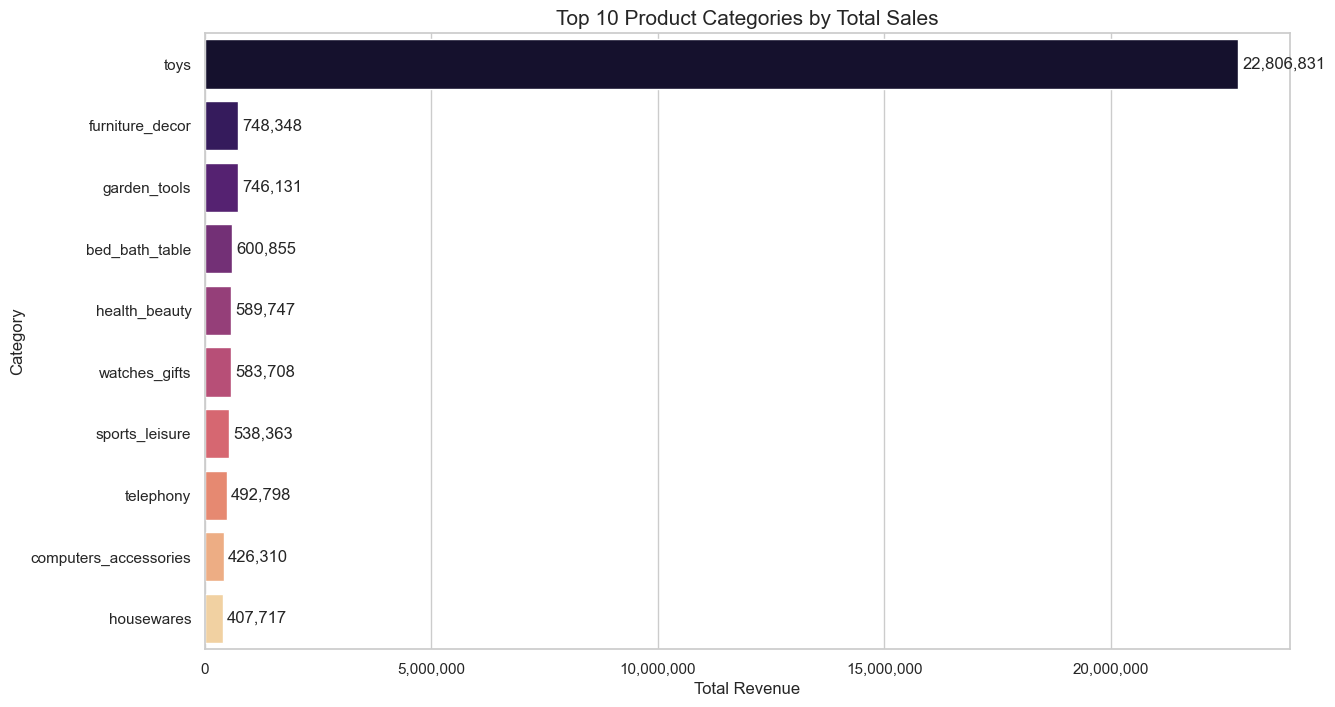

In [140]:
# 1. Source data / Dati di origine
final_df = merged_df.merge(dfproducts, on=['product_id'])

# 2. Calculate metrics per Category / Calcolo le metriche per categoria
top_categories = final_df.groupby('product_category').agg(
    total_sales=('price', 'sum'),
    quantity_sold=('product_id', 'count')
).sort_values(by='total_sales', ascending=False)

# 3. Prepare the data for the graph (Top 10) / Prepararo i dati per il grafico (Top 10)
plot_data = top_categories.head(10).reset_index()
plot_data['total_sales'] = plot_data['total_sales'].astype(int)

# 4. Create the visualization / Creo la visualizzazione
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
ax=sns.barplot(
    data=plot_data, 
    x='total_sales', 
    y='product_category', 
    palette='magma',
    hue='product_category'
)

# 5. Format X-axis to show integers (no decimals) / Formatto l'asse X per mostrare i numeri interi (senza decimali)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}')) # from matplotlib.ticker import FuncFormatter

# 6. Add integer data labels to the bars / Aggiungo le etichette di dati interi alle barre
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

# 7. Title and labels / Titolo ed etichette
plt.title('Top 10 Product Categories by Total Sales', fontsize=15)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Category', fontsize=12)

# 8. Save and Dispplay / Salva e visualizza
plt.savefig('Top 10 Product Categories by Total Sales.png', dpi=300)
plt.show()

#### Performance di prodotto: Rapporto tra percentuale del fatturato e percentuale dei volumi venduti.
- Utilizzando il grafico a dispersione

#### Quadranti delle Prestazioni Chiave
La posizione delle bolle sul grafico permette di classificare i prodotti in quattro aree strategiche:
-	<b>In alto a destra (Alta % vendite, Alta % quantità)</b>: questi sono i prodotti "Star". Si tratta di articoli ad alta domanda che contribuiscono in modo significativo al fatturato complessivo.
-	<b>In basso a destra (Alta % vendite, Bassa % quantità)</b>: questi rappresentano gli articoli "Premium". Sebbene venduti in volumi inferiori, l'elevato valore unitario garantisce un'alta incidenza sul valore totale delle vendite.
-	<b>In alto a sinistra (Bassa % vendite, Alta % quantità)</b>: questi sono i "Volume Driver". Prodotti venduti in grandi quantità ma con prezzi o margini inferiori, che contribuiscono in misura limitata al valore totale delle vendite.
-	<b>In basso a sinistra (Bassa % vendite, Bassa % quantità)</b>: uesti sono i prodotti "Underperformer" o di nicchia, con un contributo minimo sia in termini di volume che di valore.

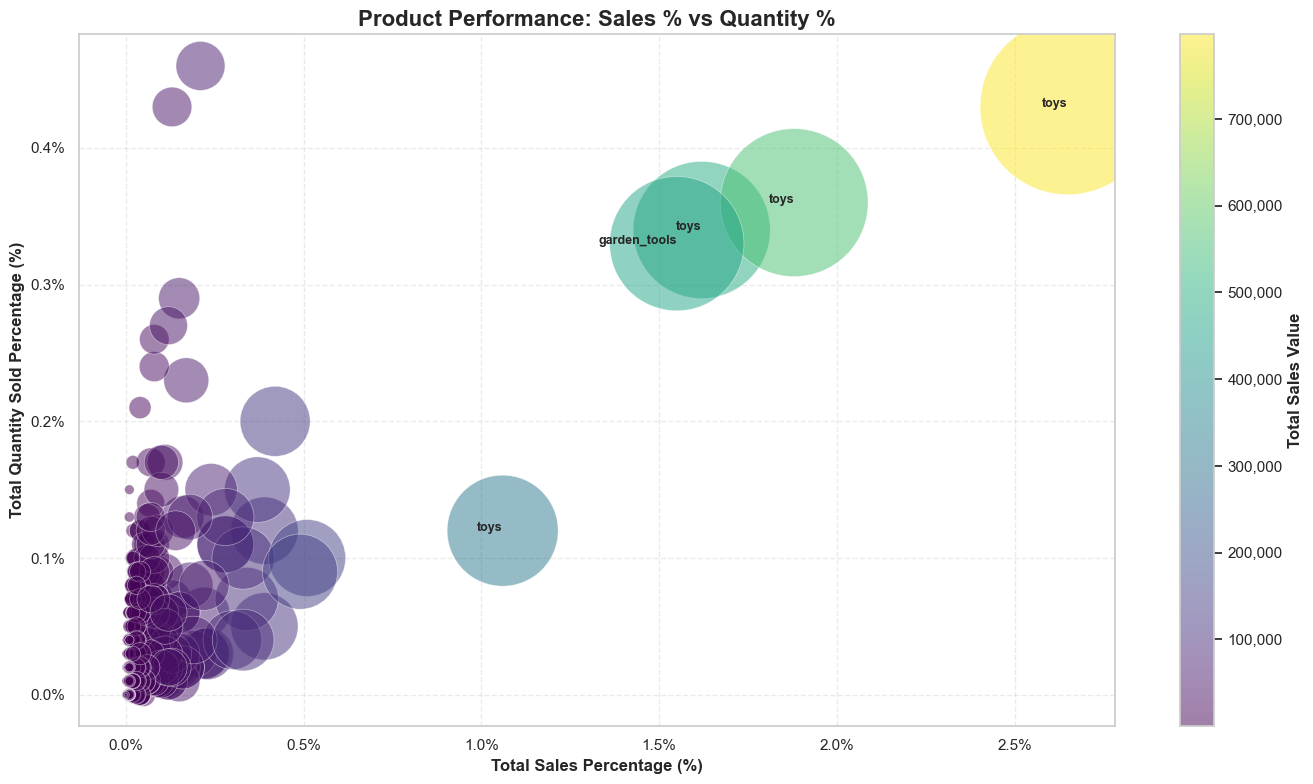

In [ ]:
# 1. Prepare Numeric Data / Preparo dato numerici
# Convert percentage strings back to floats for plotting / Converto le stringhe in float per la rappresentazione grafica
product_stats['sales_val'] = product_stats['sales_percentage'].str.rstrip('%').astype(float)
product_stats['qty_val'] = product_stats['quantity_percentage'].str.rstrip('%').astype(float)

# 2. Setup Figure
plt.figure(figsize=(14, 8))

# 3. Create Scatter Plot / Creo grafico a dispersione
# s=product_stats['total_sales'] controls the size of the bubbles / controlla la dimensione delle bolle
# I divide by a factor (e.g., 50) to keep bubble sizes manageable on screen
# Divido per un fattore (ad esempio, 50) per mantenere le dimensioni delle bolle gestibili sullo schermo
scatter = plt.scatter(
    x=product_stats['sales_val'], 
    y=product_stats['qty_val'], 
    s=product_stats['total_sales'] / 50,  # Adjust the divisor to resize bubbles / Regola il divisore per ridimensionare le bolle
    alpha=0.5, 
    c=product_stats['total_sales'],      # Color represents sales / Il colore rappresenta le vendite
    cmap='viridis', 
    edgecolors='w', 
    linewidth=0.5
)

# 4. Add a colorbar (To show the Total Sales scale) / Aggiungo una barra colorata (per mostrare la scala delle vendite totali)
cbar = plt.colorbar(scatter)
cbar.set_label('Total Sales Value', fontsize=12, fontweight='bold')
# Format colorbar numbers with thousand separators and no decimals / Formatta i numeri della barra colorata con separatori delle migliaia e senza decimali
cbar.ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Title and Labels / Titolo ed etichette
plt.title('Product Performance: Sales % vs Quantity %', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales Percentage (%)', fontsize=12, fontweight='bold')
plt.ylabel('Total Quantity Sold Percentage (%)', fontsize=12, fontweight='bold')

# Format axes to show whole numbers / Formatta gli assi per mostrare i numeri interi
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

plt.grid(True, linestyle='--', alpha=0.4)

# 6. Annotate top products (Optional) / Annota i prodotti più venduti (facoltativo)
# Labels only the top 5 products by sales to avoid clutter / Etichetta solo i 5 prodotti più venduti per evitare per evitare il disordine
top_products = product_stats.nlargest(5, 'total_sales')
for i, row in top_products.iterrows():
    plt.text(
        row['sales_val'], 
        row['qty_val'], 
        row['product_category'], 
        fontsize=9, 
        fontweight='bold',
        ha='right'
    )

# 7. Save and Dispplay / Salva e visualizza
plt.tight_layout()
plt.savefig('Product Performance on Sales Percentage vs Quantity Sold Percentage.png', dpi=300, bbox_inches='tight')
plt.show()

In [146]:
# 1. Ensure the data is sorted by revenue descending (required for cumulative calculation)
result = result.sort_values(by='total_sales', ascending=False)

# 2. Calculate the cumulative percentage for revenue
result['cum_sales_percentage'] = result['total_sales'].cumsum().round(2)

# 3. Calculate the cumulative percentage for quantity sold
result['cum_quantity_percentage'] = result['quantity_sold'].cumsum().round(2)

# 4. Filter to find the products contributing to the top 80% of revenue
top_80_sales = result[result['cum_sales_percentage'] <= 80]

print(result.head(10))

     product_id product_category  total_sales  quantity_sold sales_percentage  \
0  9NwzO0Pm0fDM             toys    797298.94            383            2.65%   
1  SLTlrWtcYt1m             toys    566543.44            320            1.88%   
2  Biwi1BNtUB7l             toys    486503.65            295            1.62%   
3  ro08JPncYzLh     garden_tools    467133.53            290            1.55%   
4  ZWyg4uNWPHjJ             toys    318890.00            110            1.06%   
5  tPlw2QcQOvKf     garden_tools    153366.49             91            0.51%   
6  utVPLgd1LM3F             toys    146223.00             77            0.49%   
7  GvBzGCvvIC2D             toys    126959.00            175            0.42%   
8  5J7az1rwth4i             toys    117385.08            110            0.39%   
9  CY8OZ3lT9uqB        telephony    116979.98             42            0.39%   

  quantity_percentage  cum_sales_percentage  cum_quantity_percentage  
0               0.43%             797

#### 4.	Geograﬁa e logistica 
-	A. Distribuzione del numero di ordini e del fatturato per lo stato.

In [147]:
print("Orders columns:", dforders.columns.tolist())
print("Order Items columns:", dforder_items.columns.tolist())

Orders columns: ['order_id', 'customer_id', 'order_status', 'order_date', 'order_approved_at', 'delivery_date', 'estimated_delivery_date', 'shipping_city', 'shipping_state', 'delay_days', 'status', 'delivery_status']
Order Items columns: ['order_item_id', 'order_id', 'product_id', 'seller_id', 'price', 'shipping_charges']


In [153]:
# 1. Clean column names (removes hidden spaces) / Pulisco i nomi delle colonne (rimuove gli spazi nascosti)
dfcustomers.columns = dfcustomers.columns.str.strip()
dforders.columns = dforders.columns.str.strip()
dforder_items.columns = dforder_items.columns.str.strip()

# 2. Reset index if 'order_id' is accidentally set as the index / Reimposto l'indice se 'order_id' viene impostato accidentalmente come indice
if 'order_id' not in dforders.columns:
    dforders = dforders.reset_index()

In [154]:
# Use left_on and right_on if column names differ / Utilizzare left_on e right_on se i nomi delle colonne sono diversi
merged_df = pd.merge(
    dforders, 
    dforder_items, 
    left_on='order_id',  # Column name in 'orders'
    right_on='order_id'  # Column name in 'order_items'
)

print(merged_df.columns) 

Index(['order_id', 'customer_id', 'order_status', 'order_date',
       'order_approved_at', 'delivery_date', 'estimated_delivery_date',
       'shipping_city', 'shipping_state', 'delay_days', 'status',
       'delivery_status', 'order_item_id', 'product_id', 'seller_id', 'price',
       'shipping_charges'],
      dtype='object')


In [159]:
# 1. Filter orders for specific statuses / Filtro gli ordini per stati specifici
valid_statuses = ['delivered', 'invoiced', 'shipped']
filtered_orders = dforders[dforders['order_status'].isin(valid_statuses)]

# 2. Merge DataFrames / Unisco DataFrames
# Use left_on and right_on if column names differ
merged_df = pd.merge(
    dforders, 
    dforder_items, 
    left_on='order_id',  # Column name in 'orders'
    right_on='order_id'  # Column name in 'order_items'
)
final_df = pd.merge(merged_df, dfcustomers, on='customer_id', how='inner')

# 3. Aggregate by state using the specific suffixed columns from my final_df
# Aggregare per lo stato utilizzando le colonne con suffisso specifico dal mio final_df
state_analysis = final_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    total_sales=('price', 'sum')
).sort_values(by='total_sales', ascending=False).reset_index()

# 4. Reset the index so 'customer_state' is a regular column again
# Reimposto l'indice in modo che 'customer_state' sia di nuovo una colonna normale
plot_df = state_analysis.reset_index()

# Display the results / Visualizza i risultati
print("Number of Orders and Total Sales per Customer State:")
pd.set_option('display.max_rows', 30) # to set maximum rows to display
display(state_analysis)

Number of Orders and Total Sales per Customer State:


,customer_state,total_orders,total_sales
0,SP,37387,12826321.35
1,RJ,11477,3825670.78
2,MG,10235,3484962.45
3,RS,4873,1649366.96
4,PR,4481,1595811.15
5,SC,3182,1055801.59
6,BA,3062,1053643.31
7,GO,1847,677601.72
8,ES,1787,613076.50
9,DF,1778,563955.81


#### Analisi del risultato di un grafico a barre sulle vendite per lo Stato
- Il grafico a barre ci consente di valutare le performance regionali e la concentrazione del mercato. Poiché ordino i dati in base alle vendite totali in ordine decrescente, la visualizzazione risultante evidenzia immediatamente i mercati più critici.

#### Concentrazione di mercato
- <b>Top Performers</b>: Le prime barre a sinistra rappresentano gli stati "anchor". Si tratta delle regioni in cui l'azienda ha la maggiore penetrazione di mercato o in cui si concentrano clienti di alto valore.
- <b>La coda lunga</b>: Man mano che le barre scendono verso destra, possiamo identificare gli stati "di coda" con vendite e fatturato bassi. Questo aiuta a determinare se le risorse (come le spese di marketing o la logistica delle spedizioni) vengono distribuite in modo efficiente nell'area geografica di riferimento. 


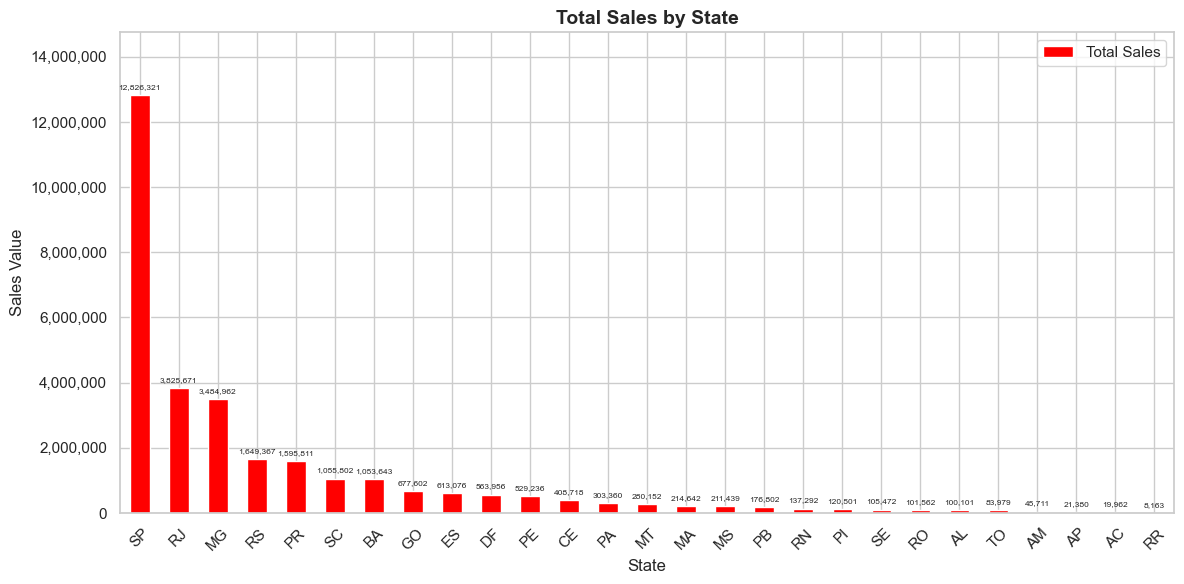

In [160]:
# 1. Create the Bar Graph / Creo il grafico a barre
# Capture the 'ax' object to modify axis and labels / attura l'oggetto 'ax' per modificare l'asse e le etichette
ax = plot_df.plot(
    kind='bar', 
    x='customer_state', 
    y='total_sales', 
    figsize=(12, 6), 
    color='red',
    legend=True,          # Add Legend
    label='Total Sales'   # Name for the legend
)

# 2. I use a formatter to show whole numbers with thousand separators
# Utilizzo un formattatore per mostrare numeri interi con separatori delle migliaia
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 3. Indicate values on the bar graph / Indico i valori sul grafico a barre
# 'containers[0]' refers to the bars created in the plot
ax.bar_label(ax.containers[0], padding=3, fmt='{:,.0f}', fontsize=6)

# 4. Final Formatting / Formattazione finale
plt.title('Total Sales by State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Sales Value', fontsize=12)
plt.xticks(rotation=45)

# Setting Y-limit higher gives labels breathing room at the top
# Impostando un limite Y più alto si dà alle etichette un margine di manovra nella parte superiore
ax.set_ylim(0, plot_df['total_sales'].max() * 1.15) # fatto le etichette dei dati siano leggibili e non tagliate dalla parte superiore del grafico

# 5. Save and Display / Salva e visualizza
plt.tight_layout()
plt.savefig('Total Sales by State.png', dpi=300, bbox_inches='tight')
plt.show()

- Distribuzione del numero di ordini e del fatturato per lo stato
- Due grafici a barre che rappresentano individualmente il numero totale di ordini per lo stato e le vendite totali per lo stato

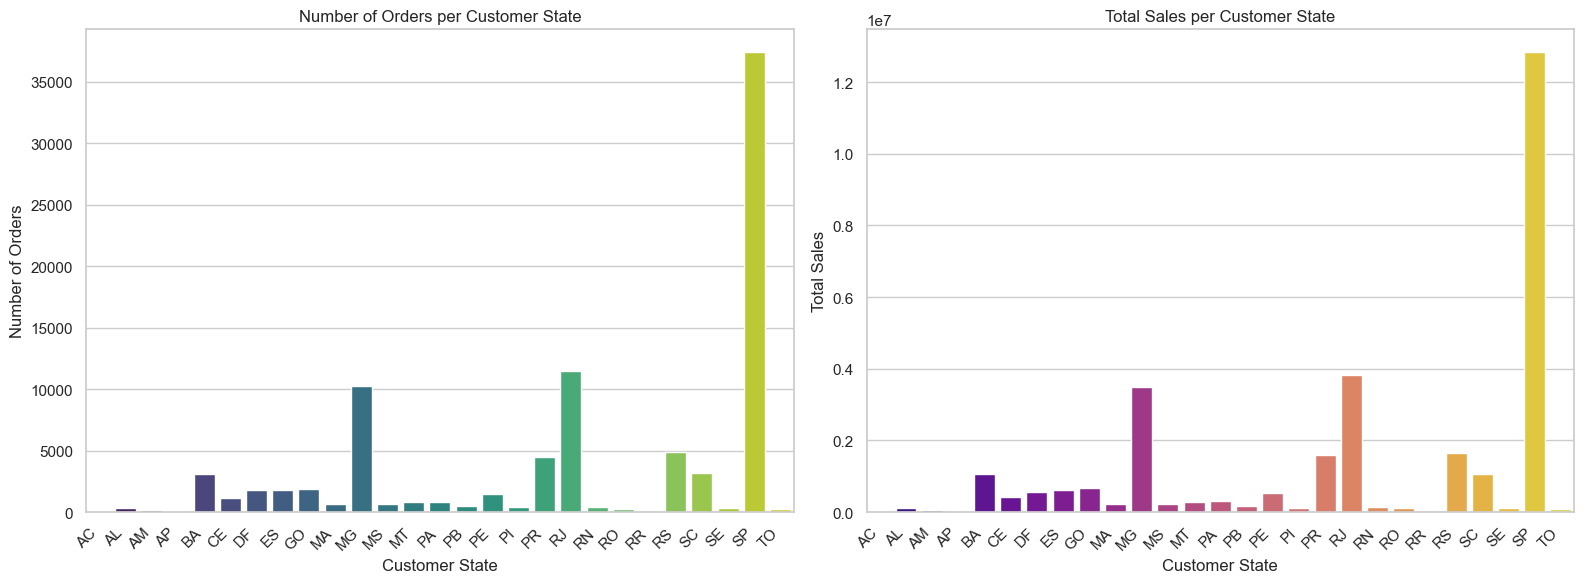

In [162]:
# 1. Aggregate by state using the specific suffixed columns/ Aggregare per stato utilizzando le colonne con suffisso specifico
# Aggregate and then MANUALLY set column names to avoid any index or naming issues
# Aggregare e impostare MANUALMENTE i nomi delle colonne per evitare problemi di indice o di denominazione
state_analysis = final_df.groupby('customer_state').agg({
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

# 2. FORCE exact column names to match my sns.barplot call
# Rinomino le colonne per farle coincidere esattamente con i parametri di sns.barplot
state_analysis.columns = ['customer_state', 'orders_count', 'total_sales']

# 3. Clean names just in case there are hidden spaces / Pulisco il nome nel caso ci siano spazi nascosti
state_analysis.columns = state_analysis.columns.str.strip()

# 4. Visualization
plt.figure(figsize=(16, 6))

# Plotting Number of Orders per State / Tracciamento del numero di ordini per lo stato
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='customer_state', y='orders_count', data=state_analysis, palette='viridis', hue='customer_state', )
plt.title('Number of Orders per Customer State')
plt.xlabel('Customer State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')

# Plotting Total Sales per State / Visualizzazione delle vendite totali per stato tramite grafico
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='customer_state', y='total_sales', data=state_analysis, palette='plasma', hue='customer_state')
plt.title('Total Sales per Customer State')
plt.xlabel('Customer State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

# 5. Save and Display / Salva e visualizza
plt.tight_layout()
plt.savefig('Number of Orders and Total Sales per Customer State.png', dpi=300, bbox_inches='tight')
plt.show()

#### Efficienza del mercato e Valore Medio dell'Ordine (AOV - Average Order Value)
1. Creao un grafico combinato a barre e linee
  - Lo scopo principale di questo grafico a doppio asse è verificare se il volume degli ordini (linea) è proporzionale alle vendite totali (barre).
2. Aggregate and sort ALFABETICAMENTE per lo stato - Performance geografica
  - Poiché i dati sono ordinati alfabeticamente, questo grafico funziona come un catalogo regionale. Si tratta meno di classificare i "migliori risultati" e più di identificare rapidamente le performance di specifici stati. Questa visualizzazione è particolarmente utile per i responsabili regionali per individuare il loro territorio specifico e verificare se il loro rapporto vendite/ordini è soddisfacente rispetto agli stati limitrofi.

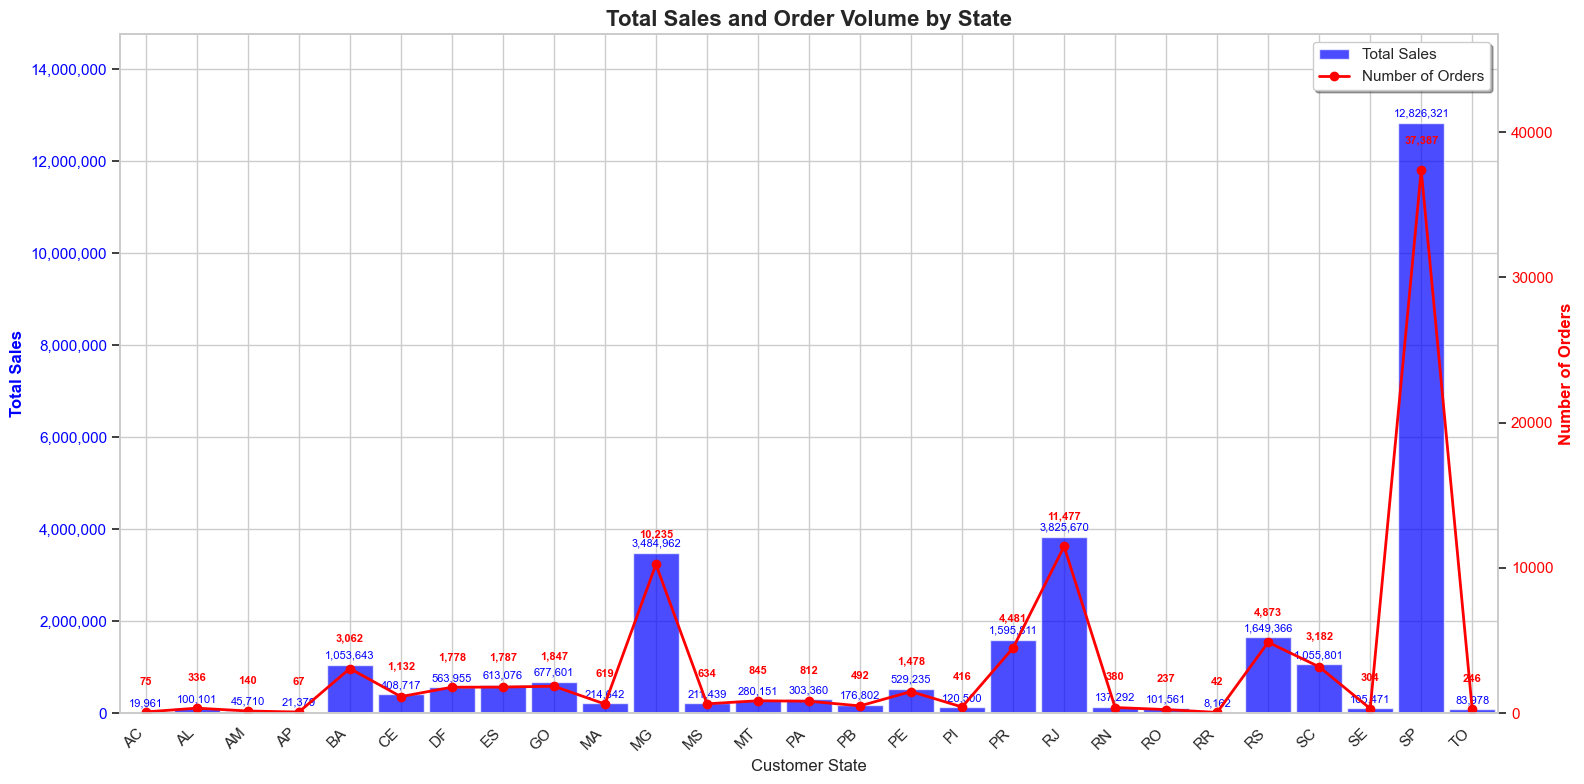

In [164]:
# 1. Aggregate and sort ALPHABETICALLY by state / Aggregare e ordinare ALFABETICAMENTE per lo stato
state_analysis = final_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    total_sales=('price', 'sum')
).sort_values(by='customer_state', ascending=True).reset_index()

# 2. Ensure Sales are integers for the data / Assicurarsi che le vendite siano numeri interi per i dati
state_analysis['total_sales'] = state_analysis['total_sales'].astype(int)

# 1. Setup Figure / Graph Plotting
fig, ax1 = plt.subplots(figsize=(16, 8))

# 2. Plot Primary Axis (Bars for Sales) / Plot l'asse primario (barre per le vendite)
bar_color = 'blue'
# Usiamo range(len(...)) per assicurarci che le barre siano posizionate correttamente sugli indici
bars = ax1.bar(state_analysis['customer_state'], state_analysis['total_sales'], 
               color=bar_color, label='Total Sales', alpha=0.7, width=0.9)

ax1.set_xlabel('Customer State', fontsize=12)
ax1.set_ylabel('Total Sales', fontsize=12, color='blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')

# 3. Format Left Y-Axis: No decimals and put thousand separators
# Formato Asse Y sinistro: nessun separatore di decimali e con separatori delle migliaia
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.set_ylabel('Total Sales', fontsize=12, color='blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')

# 4. Add values on top of Bars / Aggiungo valori sopra le barre
ax1.bar_label(ax1.containers[0], fmt='{:,.0f}', padding=3, color='blue', fontsize=8)

# 5. Create Secondary Axis (Line for Orders) / Plot Total Orders (Line Graph)
# Creazione del secondo asse (Destro - Order Count)
ax2 = ax1.twinx()
ax2.plot(state_analysis['customer_state'], state_analysis['total_orders'], 
         color=line_color, marker='o', linewidth=2, label='Number of Orders')

ax2.set_ylabel('Total Order Count', fontsize=12, color=line_color, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=line_color)

# 6. Add values on the Line points / Aggiungo valori sopra le barre
for i, v in enumerate(state_analysis['total_orders']):
    ax2.text(i, v + (state_analysis['total_orders'].max() * 0.05), 
              f'{v:,.0f}', # Added comma here for labels above dots
             color='red', ha='center', fontweight='bold', fontsize=8)

ax2.set_ylabel('Number of Orders', fontsize=12, color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

# 7. Add Unified Legend / Aggiungo legenda unificata
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, shadow=True)

# 8. Final Polish
plt.title('Total Sales and Order Volume by State', fontsize=16, fontweight='bold')
ax2.grid(False) 

#  REMOVE SIDE SPACE: Set limits from the half-width of the first bar to the last
# RIMUOVO Lo SPAZIO LATERALE: Imposta i limiti dalla metà della larghezza della prima barra all'ultima
ax1.set_xlim(-0.5, len(state_analysis['customer_state']) - 0.5)

# Set Y-limit slightly higher for labels / Imposta il limite Y leggermente più alto per le etichette
ax1.set_ylim(0, state_analysis['total_sales'].max() * 1.15)
ax2.set_ylim(0, state_analysis['total_orders'].max() * 1.25)

# 9. Save and Display / Salva e visualizza
plt.tight_layout()
plt.savefig('Total Sales and Order Volume by State.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1. VERIFY: Print columns to see exactly what they are named
# VERIFICA: Stampa le colonne per vedere esattamente come sono nominate
print("Current columns in plot_df:", plot_df.columns.tolist())

Current columns in plot_df: ['index', 'customer_state', 'total_orders', 'total_sales']


#### 4.	Geograﬁa e logistica 
-	B. Analisi dei tempi di consegna e del ritardo medio rispetto alla data stimata.

In [166]:
# Ensure columns are datetime objects / Assicurarsi che le colonne siano oggetti datetime
dforders['delivery_date'] = pd.to_datetime(dforders['delivery_date'])
dforders['estimated_delivery_date'] = pd.to_datetime(dforders['estimated_delivery_date'])

# Calculate delay in days (positive means late, negative means early/on-time)
# Calcolo il ritardo in giorni (positivo significa in ritardo, negativo significa in anticipo/puntuale)
dforders['delay_days'] = (dforders['delivery_date'] - dforders['estimated_delivery_date']).dt.days

# Classify status / Classifico lo stato
dforders['status'] = dforders['delay_days'].apply(lambda x: 'Late' if x > 0 else 'On Time')

# Display counts / Visualizza i conteggi
status_counts = dforders['status'].value_counts()
print("Delivery Status Counts:\n", status_counts)

Delivery Status Counts:
 status
On Time    82760
Late        5604
Name: count, dtype: int64


#### Delivery Performance
- Grafico a barre categorico per la valutazione dell'efficienza logistica: confronto tra ordini "Late" (in ritardo) e "On Time or Early" (puntuali o in anticipo).

- Definizione del ritardo medio: Calcolo dello scostamento temporale medio degli ordini "Late" rispetto alla data di consegna stimata.

- Parametri di Valutazione: Un tasso di consegna puntuale (On-Time Delivery - OTD) ≥ 90% è considerato un indicatore di buona performance e rientra nei livelli di accettabilità. In questo caso, la valutazione dei tempi di consegna è accettabile, con una percentuale del 92,38%.

- Gravità del KPI (Average Delay): L'annotazione in rosso indica il ritardo medio, un dato critico per la valutazione dell'efficienza. Anche in presenza di una bassa percentuale di ordini in ritardo (es. 7,58%), un ritardo medio elevato (es. 10 giorni) ha un impatto devastante sulla reputazione del brand.

Delivery Status Counts and Percentages:
     Delivery_Status  Order_Count Percentage
0  On Time or Early        81627     92.38%
1              Late         6737      7.62%
Average Delay for Late Orders: 8.694968086685469


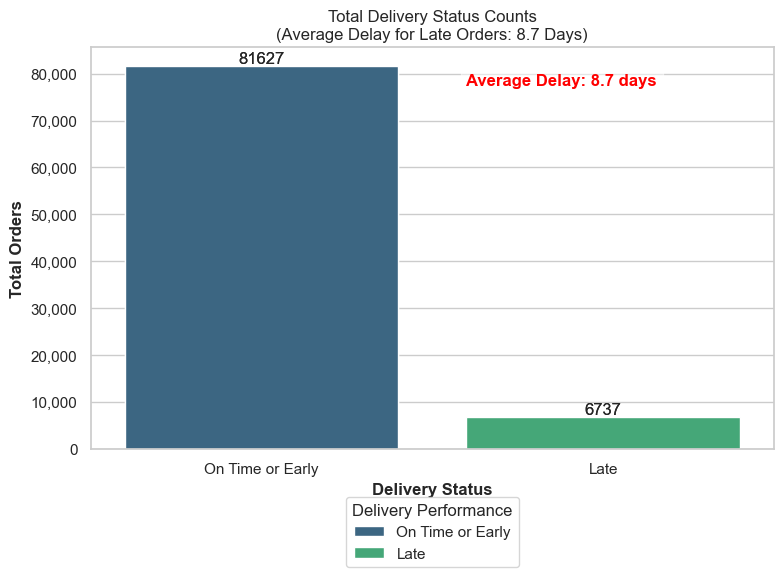

In [ ]:
# 1. Define the conditions (CASE logic) / Definire le condizioni (logica CASE)
conditions = [
    (dforders['delivery_date'] > dforders['estimated_delivery_date']),
    (dforders['delivery_date'] <= dforders['estimated_delivery_date'])
]

# 2. Define the corresponding labels (THEN/ELSE) / Definisco le etichette corrispondenti (THEN/ELSE)
choices = ['Late', 'On Time or Early']

# 3. Create the delivery_status column (default handles the ELSE)
# Creo la colonna delivery_status (l'impostazione predefinita gestisce ELSE)
dforders['delivery_status'] = np.select(conditions, choices, default='Status Unknown (Missing Date)')

# 4. Group by and count (GROUP BY/COUNT)
result = dforders['delivery_status'].value_counts().reset_index()
result.columns = ['Delivery_Status', 'Order_Count']

# 5. Calculate Percentage / Calcolo la percentuale
result['Percentage'] = (result['Order_Count'] / result['Order_Count'].sum()) * 100
result['Percentage'] = result['Percentage'].map('{:.2f}%'.format)
print("Delivery Status Counts and Percentages:\n", result)

# 6. Ensure columns are in datetime format / Assicuro che le colonne siano in formato data/ora
dforders['delivery_date'] = pd.to_datetime(dforders['delivery_date'])
dforders['estimated_delivery_date'] = pd.to_datetime(dforders['estimated_delivery_date'])

# 7. Filter for late orders / Filtro per ordini in ritardo (WHERE delivery_date > estimated_delivery_date)
late_orders = dforders[dforders['delivery_date'] > dforders['estimated_delivery_date']].copy()

# 8. Calculate difference in days and get the average / Calcolo la differenza e la media(AVG and DATEDIFF)
# Use .dt.days to extract the integer count of days / Utilizzo .dt.days per estrarre il conteggio intero dei giorni
average_delay = (late_orders['delivery_date'] - late_orders['estimated_delivery_date']).dt.days.mean()
print(f"Average Delay for Late Orders: {average_delay}")

# 9. Using my 'result' DataFrame directly / Utilizzo diretto del DataFrame "result"
plt.figure(figsize=(8, 6))
sns.barplot(data=result, x='Delivery_Status', y='Order_Count', palette='viridis', hue='Delivery_Status')

ax = sns.barplot(
    data=result, 
    x='Delivery_Status', 
    y='Order_Count', 
    palette='viridis', 
    hue='Delivery_Status', 
    legend=True
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Optional: Add data labels on top of bars for more clarity
# Facoltativo: aggiungo le etichette dati sopra le barre per maggiore chiarezza
for i in ax.containers:
    ax.bar_label(i)

# 10. Add average delay annotation / Aggiungo l'annotazioe per il ritardo medio
plt.text(
    x=0.6, 
    y=result['Order_Count'].max() * 0.95, 
    s=f"Average Delay: {average_delay:.1f} days", 
    color='red', 
    fontweight='bold',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.5)
)

# 11. Title and axis labels / Etichette del titolo e degli assi
plt.title('Total Delivery Status Counts\n' + f'(Average Delay for Late Orders: {average_delay:.1f} Days)', fontsize=12)
plt.ylabel('Total Orders', fontweight='bold')
plt.xlabel('Delivery Status', fontweight='bold')
handles, labels = ax.get_legend_handles_labels()

plt.legend(
    handles, 
    labels, 
    title="Delivery Performance", 
    #bbox_to_anchor=(1.05, 1), 
    bbox_to_anchor=(0.5, -0.1),  # x=0.5 (centro), y=-0.15 (sotto plot)
    loc='upper center'
)

# 12. Save and Display / Salva e visualizza
plt.tight_layout()
plt.savefig('Total Delivery Status Counts On Time vs Delay.png', dpi=300, bbox_inches='tight')
plt.show()


Filtered Delivery Status (delivered, shipped, invoice):
     Delivery_Status  Order_Count  Percentage_Numeric Percentage
0  On Time or Early        81627           92.375854     92.38%
1              Late         6737            7.624146      7.62%
Average Delay for Late Orders: 8.69 days


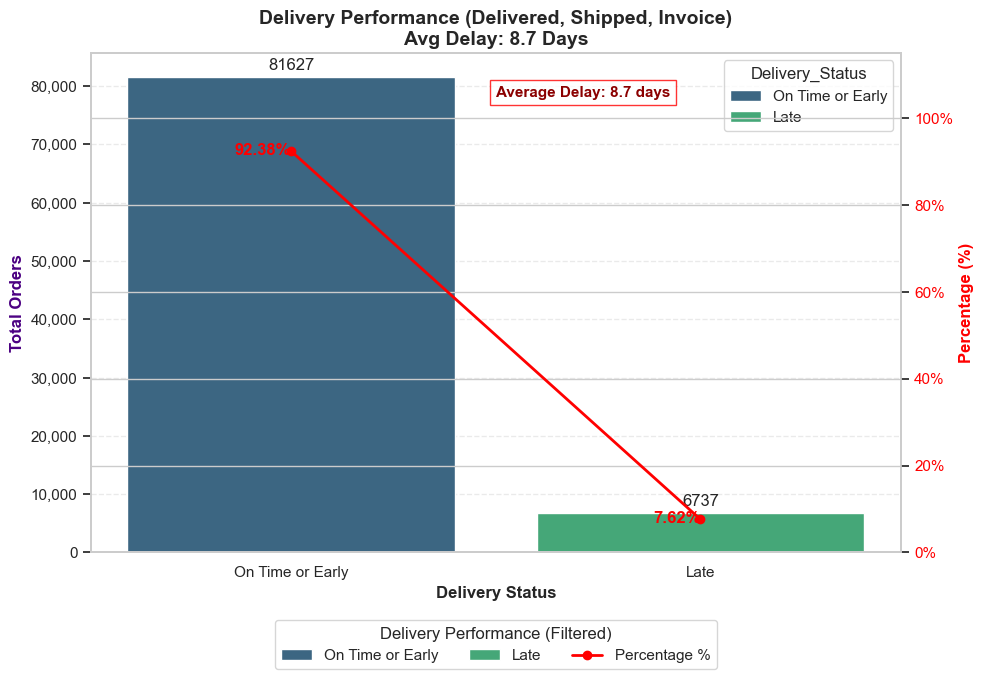

In [173]:
# 1. FILTER BY STATUS / Filtro per stato dell'ordine
# Filter immediately so all calculations only consider these statuses / Filtro immediatamente in modo che tutti i calcoli considerino solo questi stati
allowed_statuses = ['delivered', 'shipped', 'invoice']
dforders = dforders[dforders['order_status'].isin(allowed_statuses)].copy()

# 2. Ensure columns are in datetime format / Assicurarsi formato data/ora
dforders['delivery_date'] = pd.to_datetime(dforders['delivery_date'])
dforders['estimated_delivery_date'] = pd.to_datetime(dforders['estimated_delivery_date'])

# 3. Define the conditions (CASE logic) / Definisco le condizioni (logica CASE)
conditions = [
    (dforders['delivery_date'] > dforders['estimated_delivery_date']),
    (dforders['delivery_date'] <= dforders['estimated_delivery_date'])
]

# 4. Define the corresponding labels (THEN/ELSE) / Definisco le etichette corrispondenti (THEN/ELSE)
choices = ['Late', 'On Time or Early']

# 5. Create the delivery_status column (default handles the ELSE)
# Creo la colonna delivery_status (l'impostazione predefinita gestisce ELSE)
dforders['delivery_status'] = np.select(conditions, choices, default='Status Unknown (Missing Date)')

# 6. Group by and count (GROUP BY/COUNT)
result = dforders['delivery_status'].value_counts().reset_index()
result.columns = ['Delivery_Status', 'Order_Count']

# 7. Calculate Percentage / Calcolo la percentuale
result['Percentage_Numeric'] = (result['Order_Count'] / result['Order_Count'].sum()) * 100
result['Percentage'] = result['Percentage_Numeric'].map('{:.2f}%'.format)
print("Filtered Delivery Status (delivered, shipped, invoice):\n", result)

# 8. Ensure columns are in datetime format / Assicurarsi che le colonne siano in formato data/ora
dforders['delivery_date'] = pd.to_datetime(dforders['delivery_date'])
dforders['estimated_delivery_date'] = pd.to_datetime(dforders['estimated_delivery_date'])

# 9. Filter for late orders / Filtro per ordini in ritardo (WHERE delivery_date > estimated_delivery_date)
late_orders = dforders[dforders['delivery_date'] > dforders['estimated_delivery_date']].copy()

# 10. Calculate average delay for late orders / Calcolo la differenza e la media(AVG and DATEDIFF)
# Use .dt.days to extract the integer count of days / Utilizzo .dt.days per estrarre il conteggio intero dei giorni
average_delay = (late_orders['delivery_date'] - late_orders['estimated_delivery_date']).dt.days.mean()
# Handle case where there might be no late orders to avoid errors / Gestisco i casi in cui potrebbero non esserci ordini in ritardo per evitare errori
average_delay = average_delay if pd.notnull(average_delay) else 0
print(f"Average Delay for Late Orders: {average_delay:.2f} days")

# 11. Visualization Using my 'result' DataFrame directly / Utilizzo diretto del DataFrame "result"
fig, ax1 = plt.subplots(figsize=(10, 7))

# --- BAR CHART (Order Count) ---
sns.barplot(
    data=result, 
    x='Delivery_Status', 
    y='Order_Count', 
    palette='viridis', 
    hue='Delivery_Status', 
    ax=ax1,
    legend=True
)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.set_ylabel('Total Orders', fontweight='bold', color='indigo')
ax1.set_xlabel('Delivery Status', fontweight='bold')

# Optional: Add data labels on top of bars for more clarity
# Facoltativo: aggiungo le etichette dati sopra le barre per maggiore chiarezza
for i in ax1.containers:
    ax1.bar_label(i, padding=3)

# --- LINE GRAPH (Percentage) ---
ax2 = ax1.twinx()
line_plot = ax2.plot(
    result['Delivery_Status'], 
    result['Percentage_Numeric'], 
    color='red', 
    marker='o', 
    linewidth=2, 
    label='Percentage %'
)

# Add values to the line graph / Aggiungo di valori al grafico lineare
for x, y in zip(result['Delivery_Status'], result['Percentage_Numeric']):
    ax2.text(x, y + 2, f'{y:.2f}%', color='red', fontweight='bold', ha='right', va='top')

# Formatting secondary axis
ax2.set_ylabel('Percentage (%)', fontweight='bold', color='red')
ax2.set_ylim(0, 115) 
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
ax2.tick_params(axis='y', labelcolor='red')

# 12. Add average delay annotation / Aggiungo l'annotazioe per il ritardo medio
plt.text(
    x=0.5, 
    y=105, # Positioned relative to the 0-115 scale of ax2
    s=f"Average Delay: {average_delay:.1f} days", 
    color='darkred', 
    fontweight='bold',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='red', alpha=0.8),
    transform=ax2.transData
)

# 13. Combine legends from both axes / Unifico le legende di entrambi gli assi
# Get handles/labels from ax1 (bars) and ax2 (line) / Ottengo handle/etichette da ax1 (barre) e ax2 (linea)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

plt.legend(
    handles1 + handles2, 
    labels1 + labels2, 
    title="Delivery Performance (Filtered)",
    bbox_to_anchor=(0.5, -0.12), 
    loc='upper center',
    ncol=3
)

# 14. Title and axis labels / Etichette del titolo e degli assi
plt.title(f'Delivery Performance (Delivered, Shipped, Invoice)\nAvg Delay: {average_delay:.1f} Days', 
          fontweight='bold', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# 15. Save and Display / Salva e visualizza
plt.tight_layout()
plt.savefig('Delivery Performance On Time vs Delay and Average Delay.png', dpi=300, bbox_inches='tight')
plt.show()

##### Analisi delle prestazioni di consegna (puntualità o ritardo)
- La linea tratteggiata rossa a 0 rappresenta l'obiettivo "puntuale".
- Barre a sinistra (valori negativi): rappresentano consegne anticipate. 
- Barre a destra (valori positivi): rappresentano consegne in ritardo. 
- Ne consegue un Picco Singolo (Unimodale): in cui la maggior parte degli ordini si concentra attorno a un singolo valore, che indica che il processo di consegna è stabile e prevedibile.

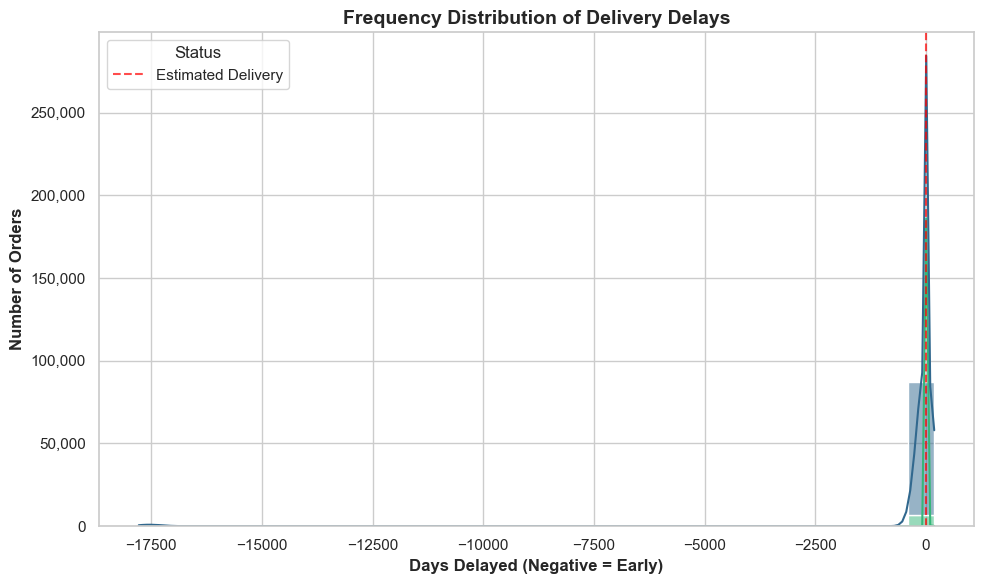

In [104]:
# 1. Calculate the delay in days / Calcolo il ritardo in giorni
dforders['delay_days'] = (dforders['delivery_date'] - dforders['estimated_delivery_date']).dt.days

# 2. Define labels / Definisco le etichette
conditions = [
    (dforders['delivery_date'] > dforders['estimated_delivery_date']),
    (dforders['delivery_date'] <= dforders['estimated_delivery_date'])
]
choices = ['Late', 'On Time or Early']
dforders['delivery_status'] = np.select(conditions, choices, default='Unknown')

# 3. Create the Histogram / Creo l'istogramma
plt.figure(figsize=(10, 6))
ax=sns.histplot(
    data=dforders, 
    x='delay_days', 
    hue='delivery_status', 
    kde=True,            # Adds a smooth trend line (Kernel Density Estimate)
    palette='viridis', 
    multiple='stack',    # Stacks bars; use 'dodge' to put them side-by-side
    bins=30              # Adjust bin count for more or less detail
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 4. Title and axis labels / Etichette del titolo e degli assi
plt.title('Frequency Distribution of Delivery Delays', fontsize=14, fontweight='bold')
plt.xlabel('Days Delayed (Negative = Early)', fontweight='bold')
plt.ylabel('Number of Orders', fontweight='bold')

# Add reference line at 0 (on-time mark) / Aggiungo la linea di riferimento a 0 (segno di puntualità)
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Estimated Delivery')
plt.legend(title='Status')

# 9. Save and Display / Salva e visualizza
plt.tight_layout()
plt.savefig('Frequency Distribution of Delivery Delays.png', dpi=300, bbox_inches='tight')
plt.show()

#### 5.	Pagamenti
- A. Distribuzione dei metodi di pagamento.
- Il metodo di pagamento in cima alla classifica (credit card) indica dove i clienti si sentono più sicuri o quali strumenti hanno più a disposizione.

  payment_type  transaction_count  percentage
0  credit_card              65511   73.684862
3       wallet              17227   19.376427
2      voucher               4886    5.495630
1   debit_card               1283    1.443081


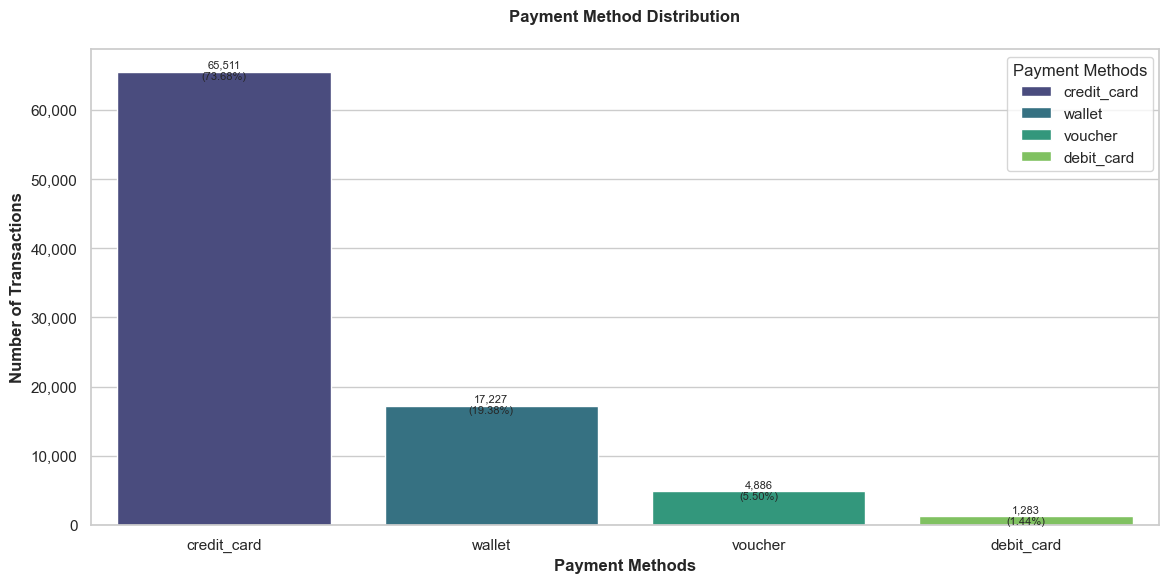

In [176]:
# 1. Data Preparation / Preparazione dei dati
distribution = dfpayments.groupby('payment_type').size().reset_index(name='transaction_count')
total_transactions = distribution['transaction_count'].sum()
distribution['percentage'] = (distribution['transaction_count'] / total_transactions) * 100
distribution = distribution.sort_values(by='transaction_count', ascending=False)
print(distribution)

# 2. Setup Figure / Graph Plotting
plt.figure(figsize=(12, 6)) # Width increased for legend space
ax = sns.barplot(
    data=distribution, 
    x='payment_type', 
    y='transaction_count', 
    palette='viridis', 
    hue='payment_type', # Mapping hue creates the distinct categories for the legend
    legend=True         # Explicitly enable legend
)

# 3. I use ax.containers and ax.bar_label for safe indexing
# Utilizzo di ax.containers e ax.bar_label per un'indicizzazione sicura
for container in ax.containers:
    # Calculate percentages for each bar in the container
    labels = []
    for v in container:
        height = v.get_height()
        if height > 0:
            pct = (height / total_transactions) * 100
            labels.append(f"{height:,.0f}\n({pct:.2f}%)")
        else:
            labels.append("")
    
    # Apply the formatted labels to the bars / Applico le etichette formattate alle barre
    ax.bar_label(container, labels=labels, padding=-7, fontsize=8)

# 4. Y-Axis and Legend / Asse Y e legenda
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(title='Payment Methods', bbox_to_anchor=(0.85, 1), loc='upper left')

# 5. Title and Layout / Titolo e Layout
plt.title('Payment Method Distribution', fontsize=12, pad=20, fontweight='bold')
plt.ylabel('Number of Transactions', fontweight='bold')
plt.xlabel('Payment Methods', fontweight='bold')
plt.tight_layout()

# 6. Save and Display / Salva e visualizza
plt.savefig('Payment Mehtod Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

- B. Relazione tra modalità di pagamento e valore medio dell’ordine.

In [ ]:
# 1. Compute the average order value per payment type or method and total transactions
# Calcolo il valore medio dell'ordine per tipo o metodo di pagamento e il totale delle transazioni
dfpayment_avg_order = (
    dfpayments.groupby('payment_type')
    .agg(
        average_order_value=('payment_value', 'mean'),  # format: (col_name, function)
        total_transactions=('payment_value', 'count')
    )
    .round({'average_order_value': 2})
    .sort_values('average_order_value', ascending=False)
    .reset_index()
)

# Display the result / Visualizza il risultato
print("\nAverage Value by Payment Method:")
print(dfpayment_avg_order)


Average Value by Payment Method:
  payment_type  average_order_value  total_transactions
0      voucher               310.42                4886
1       wallet               268.48               17227
2  credit_card               266.34               65511
3   debit_card               246.46                1283


- Presentazione grafica tra modalità di pagamento e valore medio dell'ordine.

#### Analisi comparativa tra modalità di pagamento e valore medio dell'ordine (AOV): volume delle transazioni rispetto all'Average Order Value.

- L'analisi di questo grafico a doppio asse (Dual-Axis) è fondamentale per comprendere non solo le modalità di pagamento preferite dai clienti, ma anche il valore economico che generano.

- Linee parallele: Indicano un comportamento uniforme. Il metodo di pagamento più frequente coincide con quello che genera il valore medio dell'ordine (AOV - Average Order Value) più elevato. Questa condizione è ideale per la stabilità del flusso di cassa.

- Alto Volume / Basso AOV (Picco linea blu, flessione linea rossa): Identifica i cosiddetti "pagamenti quotidiani". I clienti utilizzano questo metodo prevalentemente per acquisti d'impulso o di modesta entità.

- Basso Volume / Alto AOV (Flessione linea blu, picco linea rossa): Identifica gli "acquisti pianificati". Per i prodotti di fascia alta, i clienti tendono a preferire metodi di pagamento più sicuri o che offrono linee di credito.


Average Value by Payment Method:
  payment_type  average_order_value  total_transactions
0      voucher               310.42                4886
1       wallet               268.48               17227
2  credit_card               266.34               65511
3   debit_card               246.46                1283


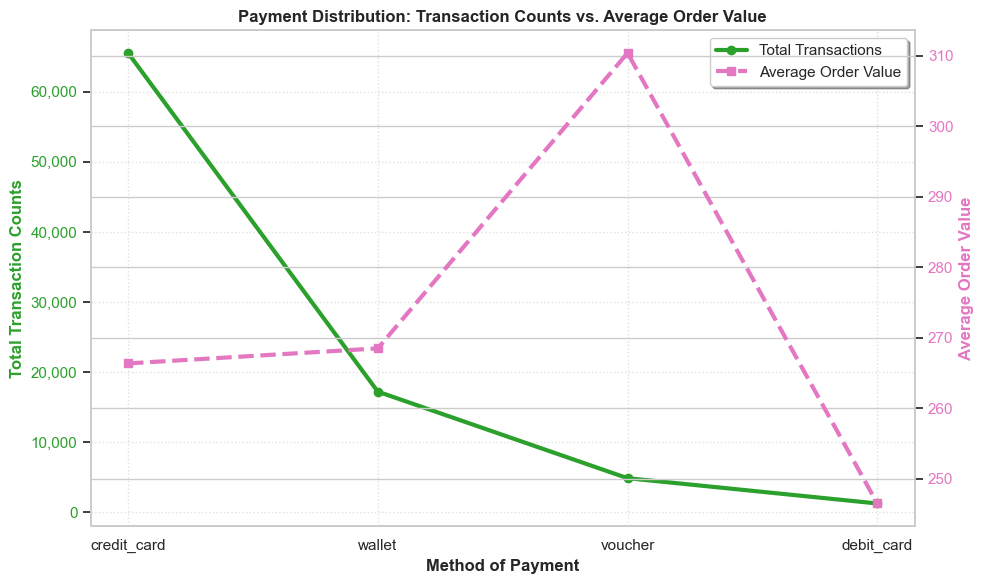

In [181]:
# Prima Parte
# 1. Compute the average order value per payment type or method and total transactions
# Calcolo il valore medio dell'ordine per tipo o metodo di pagamento e il totale delle transazioni
dfpayment_avg_order = (
    dfpayments.groupby('payment_type')
    .agg(
        average_order_value=('payment_value', 'mean'),  # format: (col_name, function)
        total_transactions=('payment_value', 'count')
    )
    .round({'average_order_value': 2})
    .sort_values('average_order_value', ascending=False)
    .reset_index()
)

# Display the result / Visualizza il risultato
print("\nAverage Value by Payment Method:")
print(dfpayment_avg_order)

# Seconda Parte
# 1. Distribution Preparation / Preparazione della Distribuzione
distribution = dfpayments.groupby('payment_type').size().reset_index(name='transaction_count')
total_transactions = distribution['transaction_count'].sum()
distribution['percentage'] = (distribution['transaction_count'] / total_transactions) * 100
distribution = distribution.sort_values(by='transaction_count', ascending=False)

# 2. Creating the 'relation' DataFrame / Creazione del DataFrame 'relation'
# Sostituisco 'payment_value' con il nome esatto della colonna del valore nel tuo df
relation = dfpayments.groupby('payment_type')['payment_value'].mean().reset_index(name='Average Order Value')

# 3. Merge the two datasets / Unisco i due set di dati
dfpayment_avg_order = pd.merge(distribution, relation, on='payment_type')

fig, ax1 = plt.subplots(figsize=(10, 6))

# 4. Line 1: Count (Left Y-axis) / Linea 1: Conteggio (Asse Y sinistro)
line1, = ax1.plot(dfpayment_avg_order['payment_type'], dfpayment_avg_order['transaction_count'], 
                  linewidth=3, marker='o', color='tab:green', label='Total Transactions ')
ax1.set_ylabel('Total Transaction Counts', color='tab:green', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.set_xlabel('Method of Payment', fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Line 2: Average Value (Right Y-Axis) / Linea 2: Valore Medio (Asse Y destro)
ax2 = ax1.twinx()
line2, = ax2.plot(dfpayment_avg_order['payment_type'], dfpayment_avg_order['Average Order Value'], 
                  linewidth=3, marker='s', color='tab:pink', linestyle='--', label='Average Order Value')
ax2.set_ylabel('Average Order Value', color='tab:pink', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='tab:pink')

# 6. --- ADDITION OF THE UNIFIED LEGEND ---  --- AGGIUNGO DELLA LEGENDA UNIFICATA ---
# I collect the lines (handles) and labels (labels) from both axes
# Raccolgo le linee (handles) e le etichette (labels) da entrambi gli assi
lines = [line1, line2]
labels = [l.get_label() for l in lines]
# Creo un'unica legenda posizionata in alto a destra
ax1.legend(lines, labels, loc='upper right', frameon=True, shadow=True)

# 6. Title and Layout / Titolo e Layout
plt.title('Payment Distribution: Transaction Counts vs. Average Order Value',fontweight='bold')
# Adds both horizontal and vertical lines to the background
# AggiungO linee orizzontali e verticali allo sfondo
ax1.grid(True, linestyle=':', alpha=0.6) 
plt.tight_layout()

# 7. Save and Display / Salva e visualizza
plt.savefig('Payment Distribution with Transaction Counts vs. Average Order Value.png', dpi=300, bbox_inches='tight')
plt.show()

In [182]:
# 1. Compute the average order value per payment type or method and total transactions
# Calcolo il valore medio dell'ordine per tipo o metodo di pagamento e il totale delle transazioni
dfpayment_avg_order = (
    dfpayments.groupby('payment_type')
    .agg(
        average_order_value=('payment_value', 'mean'),  # format: (col_name, function)
        total_order_value=('payment_value', 'sum')
    )
    .round({'average_order_value': 2})
    .sort_values('average_order_value', ascending=False)
    .reset_index()
)

# Display the result / Visualizza il risultato
print("\nAverage Value by Payment Method:")
print(dfpayment_avg_order)


Average Value by Payment Method:
  payment_type  average_order_value  total_order_value
0      voucher               310.42         1516699.33
1       wallet               268.48         4625103.62
2  credit_card               266.34        17448323.62
3   debit_card               246.46          316210.78


#### Analisi comparativa tra modalità di pagamento, valore medio e valore totale degli ordini: Valore Totale degli Ordini (Somma) vs. Valore Medio dell'Ordine (AOV).

- Il grafico fornisce una visione chiara del comportamento d'acquisto, confrontando il volume economico totale (somma) con il valore specifico di ogni transazione (media) per ciascun metodo di pagamento.

- Analisi del Valore Totale (Total Order Value - Asse Sinistro)
- Popolarità e Market Share: Il Valore Totale degli ordini riflette la diffusione del metodo. Un valore totale alto indica che quel metodo è il più utilizzato dalla base utenti, indipendentemente dal costo del singolo prodotto.

- Analisi del Valore Medio (Average Order Value - Asse Destro)
- Identificazione di Metodi "High-Ticket": I metodi di pagamento con il Valore Medio più alto (o AOV) indicano transazioni per prodotti costosi o acquisti cumulativi.

- Confronto Volume vs. Valore
- Motore di Volume: Se un metodo presenta un Totale elevato ma una Media bassa, funge da "motore di volume" (caratterizzato da molte transazioni economiche).
- Nicchia Premium: Se un metodo ha una Media alta ma un Totale basso, è usato raramente ma per ordini di valore molto elevato.



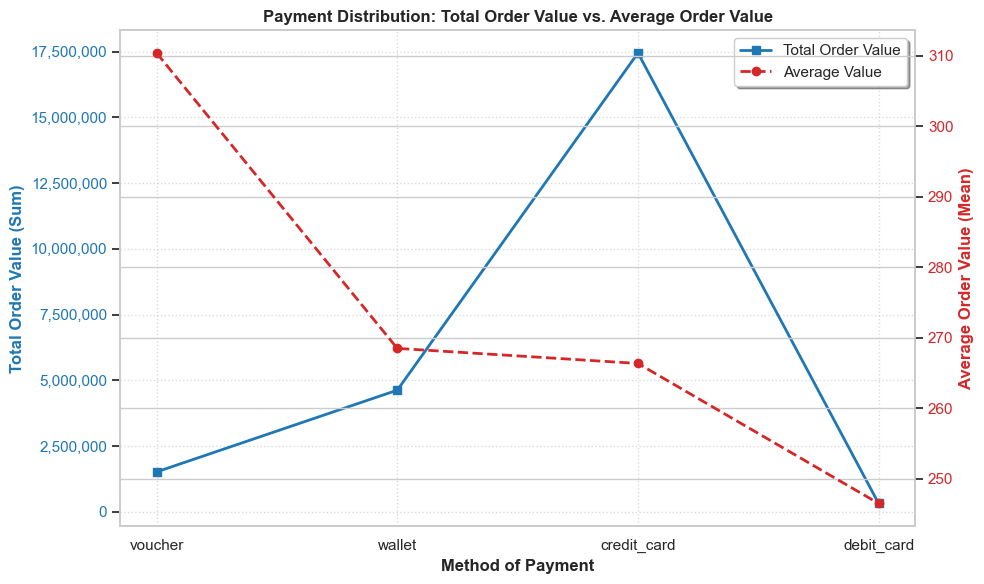

In [183]:
# 1. Calculate average and total sum using agg() / Calcolo media e somma totale usando agg()
# I use a dictionary to specify the desired aggregations for the 'payment_value' column.
# Utilizzo un dizionario per specificare le aggregazioni desiderate per la colonna 'payment_value'
payment_summary = dfpayments.groupby('payment_type').agg(
    Average_Value=('payment_value', 'mean'),
    Total_Order_Value=('payment_value', 'sum')
).reset_index().sort_values(by='Average_Value', ascending=False)

# 2. Creating the Chart / Creazione del Grafico
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3 --- LINE 1: Total Value (Left Axis - Integers) --- / --- LINEA 1: Valore Totale (Asse Sinistro - Interi) ---
line1, = ax1.plot(payment_summary['payment_type'], payment_summary['Total_Order_Value'], 
                  color='tab:blue', marker='s', linewidth=2, label='Total Order Value')

# Formattazione asse sinistro come numeri interi con separatore migliaia
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.set_ylabel('Total Order Value (Sum)', color='tab:blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xlabel('Method of Payment', fontweight='bold')

# 4. --- LINE 2: Average Value (Right Axis - Decimals) --- / --- LINEA 2: Valore Medio (Asse Destro - Decimali) ---
ax2 = ax1.twinx()
line2, = ax2.plot(payment_summary['payment_type'], payment_summary['Average_Value'], 
                  color='tab:red', marker='o', linestyle='--', linewidth=2, label='Average Value')
ax2.set_ylabel('Average Order Value (Mean)', color='tab:red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 5. --- Legend, grid and title --- / --- Legenda, grilia e titolo ---
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True, shadow=True)
plt.title('Payment Distribution: Total Order Value vs. Average Order Value', fontweight='bold')
ax1.grid(axis='both', linestyle=':', alpha=0.7)
plt.tight_layout()

# 6. Save and Display / Salva e visualizza
plt.savefig('Payment Distribution with Total Order Value vs. Average Order Value.png', dpi=300, bbox_inches='tight')
plt.show()